# **Automated Analysis Pipeline Notebook**
## Diabetes Prediction and Automated Analysis

**Student Name:** `Kundan Rao`

---

**Dataset:** Pima Indians Diabetes Database (NIH–NIDDK)

**Description:** This dataset contains diagnostic measurements from women aged 21 years or older of Pima Indian heritage. The binary prediction task is to classify whether a patient has diabetes based on the available predictor variables.

**Notebook Purpose:** Demonstrate data exploration, inferential statistics, and automated machine learning workflows, including data ingestion, missing-value handling, preprocessing, model training, and evaluation.

**Note:** This dataset is used for instructional and demonstration purposes only.

### **Assignment Description**

The purpose of the Automated Analysis Pipeline Exploration assignment is to strengthen students' understanding of how structured, reproducible, and adaptive analytical workflows are developed in health data science. Students will execute, examine, and modify a provided automated analysis pipeline to explore how foundational programming concepts, conditional logic, data exploration, and analytical decision-making work together to support automated analyses. This assignment emphasizes analytical reasoning, workflow organization, code readability, reproducibility, and the practical integration of statistical and machine learning methods within a health data science context.

Your task is to implement and execute **at least four additional examples of automated analysis code** in Google Colab beyond those provided. Examine how your workflow responds to dataset characteristics and user-defined goals. Identify the conditional logic used to automate decisions, explain the purpose of each pipeline stage, interpret the outputs (as needed), and modify selected workflow components to demonstrate how those changes affect the analysis. The links below jump to the corresponding code blocks within your copy of the notebook.

**Examples:**
1. **[Automated data ingestion](#scrollTo=OVaf3I1zyE70):** Identifies the file format and uses conditional logic to automatically select the appropriate method for reading and loading the data.

2. **Automated identification and reporting of invalid and missing values:** This process uses two consecutive blocks:
   - **[Identify known impossible values for later imputation](#scrollTo=_1r0rJ1BCX2v):** Uses a predefined list of variables to automatically replace known invalid zeros with missing values. The variable list requires knowledge of the dataset.
   - **[Automatically identify missing values in numeric predictors](#scrollTo=njK9LR0r3c7U):** Automatically identifies numeric predictors and reports their missing-value counts, including missing values created by the preceding block.

   These blocks prepare and inspect the data. Later, the machine learning pipeline fills missing predictors using medians learned from the training set and applies those same medians to the test set.

3. **[Configure and split data for the automated ML pipeline](#scrollTo=0aiR0U5sCiM-):** Uses the specified outcome variable to automatically separate predictors from the outcome, exclude rows with missing outcomes, check for numeric predictors and a binary outcome coded 0/1, and split the data into 70% training and 30% testing while preserving class proportions.

4. **[Automatically preprocess, train, and evaluate ML models](#scrollTo=l7Vt_M-pCpq0):** Automatically fills missing predictors using training-set medians, scales predictors for logistic regression, and trains logistic regression and decision tree models. Evaluates both models on the same test set, displays confusion matrices, and generates a comparison table with accuracy, recall, precision, F1, and ROC AUC scores.

In [1]:
# @title **Upload your dataset**

from google.colab import files
import pandas as pd
import io
from pathlib import Path

uploaded = files.upload()

if len(uploaded) != 1:
    raise ValueError("Please upload exactly one data file.")

filename = next(iter(uploaded))
extension = Path(filename).suffix.lower()
file_data = io.BytesIO(uploaded[filename])

if extension in [".csv", ".tsv", ".txt"]:
    # Automatically detect the delimiter.
    df = pd.read_csv(file_data, sep=None, engine="python")

elif extension in [".xlsx", ".xls"]:
    # Load the first worksheet.
    df = pd.read_excel(file_data)

elif extension == ".json":
    df = pd.read_json(file_data)

elif extension == ".parquet":
    df = pd.read_parquet(file_data)

else:
    raise ValueError(
        f"'{extension}' files require a different reader. "
        "Supported formats: CSV, TSV, TXT, XLSX, XLS, JSON, and Parquet."
    )

print(f"Successfully loaded: {filename}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

display(df.head())

Saving diabetes.csv to diabetes (1).csv
Successfully loaded: diabetes (1).csv
Rows: 768 | Columns: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [2]:
# @title **View first 10 rows of data**

df.head(10) # CHANGE NUMBER TO INCREASE OR DECREASE THE NUMBER OF ROWS

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


In [3]:
# @title **View a list of all variables**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
attribute_list = list(df.columns)
print("Variables in the dataset:")
print("")
print(attribute_list)

Variables in the dataset:

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [4]:
# @title **View the number of rows and columns in the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
print("Number of rows and columns:")
print("")
df.shape   # (rows, columns)

Number of rows and columns:



(768, 9)

In [5]:
# @title **View general information about the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [6]:
# @title **Describe the data (and data type) for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Describe all columns
summary = df.describe(include='all').T

# Replace NaN values with 'NA'
summary = summary.fillna('NA')

# Insert formatted variable name + data type
summary.insert(
    0,
    'Variable',
    [f"<b>{col}</b><br><span style='font-weight:normal; font-size:smaller;'>[{df[col].dtype}]</span>" for col in summary.index]
)

# Reset index to clean up formatting
summary.reset_index(drop=True, inplace=True)

# Format numeric columns to 3 decimal places only
styled_summary = (
    summary.style
    .format(precision=3, na_rep="NA")  # Format numbers to 3 decimals
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .hide(axis='index')  # Remove default row index
)

styled_summary

Variable,count,mean,std,min,25%,50%,75%,max
Pregnancies[int64],768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose[int64],768.000,121.677,30.464,44.000,99.750,117.000,140.250,199.000
BloodPressure[float64],768.000,72.389,12.106,24.000,64.000,72.000,80.000,122.000
SkinThickness[int64],768.000,29.090,8.891,7.000,25.000,28.000,32.000,99.000
Insulin[float64],768.000,141.754,89.101,14.000,102.500,102.500,169.500,846.000
BMI[float64],768.000,32.435,6.880,18.200,27.500,32.050,36.600,67.100
DiabetesPedigreeFunction[float64],768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age[int64],768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome[int64],768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [7]:
# @title **Identify known impossible values for later imputation**

import numpy as np

variables_to_replace_zeros = [
    'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI' #MODIFIED-------------------
]

for variable in variables_to_replace_zeros:
    if variable in df.columns:
        df[variable] = df[variable].replace(0, np.nan)

print("Impossible zeros replaced with missing values.")
print("The ML pipeline will impute missing predictors using training data.")

Impossible zeros replaced with missing values.
The ML pipeline will impute missing predictors using training data.


In [8]:
# @title **Automatically identify other missing values in numeric predictors**

target_variable = "Outcome"

# Automatically identify numeric predictors.
numeric_predictors = df.select_dtypes(include="number").columns
numeric_predictors = numeric_predictors.drop(
    target_variable, errors="ignore"
)

# Count missing values.
missing_counts = df[numeric_predictors].isna().sum()
predictors_with_missing = missing_counts[missing_counts > 0]

if predictors_with_missing.empty:
    print("No missing values detected in numeric predictors.")
else:
    print("Predictors requiring imputation:")
    display(predictors_with_missing.rename("Missing values").to_frame())
    print("Block #4 will automatically fill these using training-set medians.")

No missing values detected in numeric predictors.


In [9]:
# @title **Description of just one variable**

# Define the variable name (this can be dynamic)
variable = 'BMI'  # CHANGE VARIABLE HERE


#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Print the title dynamically
print(f"Quantitative Description of {variable}:")
print("")

# Get the description and round it to 3 decimal places
description = df[variable].describe().round(3)

# Print the rounded description
print(description)

Quantitative Description of BMI:

count    768.000
mean      32.435
std        6.880
min       18.200
25%       27.500
50%       32.050
75%       36.600
max       67.100
Name: BMI, dtype: float64


In [10]:
# @title **Number of responses and missing values for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Count non-null and missing responses
response_counts = df.count()
missing_counts = df.isnull().sum()

# Combine into one DataFrame
df_count = pd.DataFrame({
    'Variable': response_counts.index,
    '# of Responses': response_counts.values,
    '# Missing': missing_counts.values
})

# Display as styled table: bold headers and center-aligned values
df_count.style.set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

,Variable,# of Responses,# Missing
0,Pregnancies,768,0
1,Glucose,768,0
2,BloodPressure,768,0
3,SkinThickness,768,0
4,Insulin,768,0
5,BMI,768,0
6,DiabetesPedigreeFunction,768,0
7,Age,768,0
8,Outcome,768,0


In [11]:
# @title **A. Automated data quality report**


#Columns where a value of 0 is not physically possible
zero_not_allowed = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
missing_limit = 5   #flags column if more than 5% of its values are missing

report = []   #empty list that will hold one row of results per column

for col in df.columns:
    n_missing = df[col].isna().sum()
    n_zero = (df[col] == 0).sum()
    pct_missing = n_missing / len(df) * 100

    #Decision logic: the first condition that is True decides the label
    if col in zero_not_allowed and n_zero > 0:
        status = "PROBLEM: impossible zeros"
    elif pct_missing > missing_limit:
        status = "PROBLEM: too many missing values"
    elif n_missing > 0:
        status = "Minor: some missing values"
    else:
        status = "OK"

    report.append({
        "Column": col,
        "Missing": n_missing,
        "% Missing": round(pct_missing, 1),
        "Zeros": n_zero,
        "Status": status
    })

report_table = pd.DataFrame(report)
display(report_table)

#Summary
n_problems = report_table["Status"].str.startswith("PROBLEM").sum()
if n_problems == 0:
    print("No serious data quality problems found.")
else:
    print(f"{n_problems} column(s) need attention before analysis.")

,Column,Missing,% Missing,Zeros,Status
0,Pregnancies,0,0.0,111,OK
1,Glucose,0,0.0,0,OK
2,BloodPressure,0,0.0,0,OK
3,SkinThickness,0,0.0,0,OK
4,Insulin,0,0.0,0,OK
5,BMI,0,0.0,0,OK
6,DiabetesPedigreeFunction,0,0.0,0,OK
7,Age,0,0.0,0,OK
8,Outcome,0,0.0,500,OK


No serious data quality problems found.


### A. Purpose
Checks every column in the dataset for missing values and impossible zeros, then assigns each column a status label. It also checks the earlier cleaning block (Block 9).

### Settings the user can change
| Setting | Meaning |
|---|---|
| `zero_not_allowed` | Columns where a value of 0 is physically impossible (e.g., a blood pressure of 0) |
| `missing_limit` | Percentage of missing values above which a column is flagged |

### Functions and commands used
| Code | What it does |
|---|---|
| `report = []` | Creates an empty list to collect one row of results per column |
| `for col in df.columns:` | Loop that repeats the checks once for every column |
| `df[col].isna().sum()` | `isna()` marks missing values as True; `sum()` counts them |
| `(df[col] == 0).sum()` | Counts how many values equal exactly 0 |
| `len(df)` | Number of rows, used to turn counts into percentages |
| `if / elif / else` | Decision logic; the first condition that is True decides the label |
| `report.append({...})` | Adds one dictionary (one table row) to the list |
| `round(x, 1)` | Rounds a number to 1 decimal place |
| `pd.DataFrame(report)` | Converts the list of dictionaries into a table |
| `display()` | Shows the table in the notebook |
| `.str.startswith("PROBLEM").sum()` | Counts how many status labels begin with "PROBLEM" |
| `f"..."` (f-string) | Inserts variable values into printed text |

### Decision logic
1. If the column is in `zero_not_allowed` **and** contains zeros → **PROBLEM: impossible zeros**
2. Otherwise, if more than `missing_limit` percent is missing → **PROBLEM: too many missing values**
3. Otherwise, if any values are missing → **Minor: some missing values**
4. Otherwise → **OK**

A final `if/else` prints a summary message depending on whether any PROBLEM labels were found.

### Output
A table with one row per column (Missing, % Missing, Zeros, Status) and a one-line summary.

### What to look for
- Which columns, if any, were flagged?
- If a column such as `SkinThickness` is flagged for zeros, Block 9 may not have replaced them, because its variable names did not match the dataset's column names.
- If every column says OK, the data was already cleaned.

In [12]:
# @title **View 15 random rows of data**
np.random.seed(42) #MODIFIED --------------------------------------------------
df.sample(n=15) # CHANGE NUMBER HERE TO INCREASE OR DECREASE NUMBER OF RANDOM ROWS

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
668,6,98,58.0,33,190.0,34.0,0.430,43,0
324,2,112,75.0,32,102.5,35.7,0.148,21,0
624,2,108,64.0,27,102.5,30.8,0.158,21,0
690,8,107,80.0,27,102.5,24.6,0.856,34,0
473,7,136,90.0,27,102.5,29.9,0.210,50,0
204,6,103,72.0,32,190.0,37.7,0.324,55,0
97,1,71,48.0,18,76.0,20.4,0.323,22,0
336,0,117,70.0,27,102.5,33.8,0.932,44,0
568,4,154,72.0,29,126.0,31.3,0.338,37,0
148,5,147,78.0,27,102.5,33.7,0.218,65,0


In [13]:
#@title **B. Automatic variable-type detection and summary**

max_categories = 20   #MODIFIED (FROM 10)---------------------------------------
skew_limit = 10       #if mean and median differ by more than this %, call it skewed

for col in df.columns:
    n_unique = df[col].nunique()
    print("=" * 50)
    print(f"{col}  ({n_unique} unique values)")

    if n_unique <= max_categories:
        #Categorical-style summary: counts and percentages
        print("Treated as: CATEGORICAL")
        counts = df[col].value_counts()
        percents = (df[col].value_counts(normalize=True) * 100).round(1)
        display(pd.DataFrame({"Count": counts, "Percent": percents}))

    else:
        #Numeric summary: mean, median, standard deviation
        print("Treated as: NUMERIC")
        mean = df[col].mean()
        median = df[col].median()
        std = df[col].std()
        print(f"Mean = {mean:.2f} | Median = {median:.2f} | SD = {std:.2f}")

        #Compare mean and median to choose the better summary
        if median != 0:
            difference_pct = abs(mean - median) / abs(median) * 100
        else:
            difference_pct = 0

        if difference_pct > skew_limit:
            print(f"Mean and median differ by {difference_pct:.1f}% -> skewed; "
                  "the MEDIAN is the better summary.")
        else:
            print(f"Mean and median differ by {difference_pct:.1f}% -> roughly symmetric; "
                  "the MEAN is a fine summary.")

Pregnancies  (17 unique values)
Treated as: CATEGORICAL


,Count,Percent
Pregnancies,,
1,135,17.6
0,111,14.5
2,103,13.4
3,75,9.8
4,68,8.9
5,57,7.4
6,50,6.5
7,45,5.9
8,38,4.9


Glucose  (135 unique values)
Treated as: NUMERIC
Mean = 121.68 | Median = 117.00 | SD = 30.46
Mean and median differ by 4.0% -> roughly symmetric; the MEAN is a fine summary.
BloodPressure  (47 unique values)
Treated as: NUMERIC
Mean = 72.39 | Median = 72.00 | SD = 12.11
Mean and median differ by 0.5% -> roughly symmetric; the MEAN is a fine summary.
SkinThickness  (50 unique values)
Treated as: NUMERIC
Mean = 29.09 | Median = 28.00 | SD = 8.89
Mean and median differ by 3.9% -> roughly symmetric; the MEAN is a fine summary.
Insulin  (187 unique values)
Treated as: NUMERIC
Mean = 141.75 | Median = 102.50 | SD = 89.10
Mean and median differ by 38.3% -> skewed; the MEDIAN is the better summary.
BMI  (247 unique values)
Treated as: NUMERIC
Mean = 32.43 | Median = 32.05 | SD = 6.88
Mean and median differ by 1.2% -> roughly symmetric; the MEAN is a fine summary.
DiabetesPedigreeFunction  (517 unique values)
Treated as: NUMERIC
Mean = 0.47 | Median = 0.37 | SD = 0.33
Mean and median differ by

,Count,Percent
Outcome,,
0,500,65.1
1,268,34.9



##B. Purpose
Decides for each column whether it behaves like a **category** (few distinct values) or a **number** (many distinct values), then prints the type of summary that suits it. For numeric columns it also decides whether the mean or the median is the better summary.

### Settings the user can change
| Setting | Meaning |
|---|---|
| `max_categories` | A column with this many unique values or fewer is treated as categorical |
| `skew_limit` | If mean and median differ by more than this percentage, the variable is called skewed |

### Functions and commands used
| Code | What it does |
|---|---|
| `for col in df.columns:` | Repeats the steps for every column |
| `df[col].nunique()` | Counts the number of different values in a column |
| `print("=" * 50)` | Prints a line of 50 equal signs as a visual divider |
| `value_counts()` | Counts how many times each value appears |
| `value_counts(normalize=True)` | Gives proportions instead of counts; multiplied by 100 for percentages |
| `pd.DataFrame({...})` | Combines the counts and percentages into one table |
| `.mean()`, `.median()`, `.std()` | Average, middle value, and spread of a numeric column |
| `abs()` | Absolute value, so the difference is always positive |
| `f"{mean:.2f}"` | Prints a number with 2 decimal places |

### Decision logic
1. **First decision:** if `nunique() <= max_categories` → categorical summary (counts and percentages); otherwise → numeric summary (mean, median, SD).
2. **Second decision (numeric columns only):** compute the percentage difference between mean and median.
   - Difference above `skew_limit` → "skewed, use the **median**"
   - Otherwise → "roughly symmetric, the **mean** is fine"
3. A small safety check (`if median != 0`) prevents dividing by zero.

### Output
For each variable: its detected type and either a count/percent table or a mean/median/SD line with a recommendation.

### What to look for
- Which variables were treated as categorical and which as numeric?
- `Outcome` (2 values) should be categorical. `Pregnancies` is a count but has many unique values, so it is treated as numeric. The code works only from the number of unique values, not from what the variable means.
- Compare the "skewed" decisions with the histograms earlier in the notebook. Do they agree?

In [14]:
# @title **Change a variable's data type (e.g., from integer to category)**

# Choose variable to change
variable_to_change = 'Outcome' # CHANGE THIS VARIABLE
new_data_type = 'category' # CHANGE THIS TO THE NEW DATA TYPE (options include category, int64, float)

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
# Capture original data type
original_dtype = df[variable_to_change].dtype

# Change data type (options include category, float, int64)
df[variable_to_change] = df[variable_to_change].astype(new_data_type)

# Capture new data type
new_dtype = df[variable_to_change].dtype

# Print result dynamically
print(f"'{variable_to_change}' variable changed from {original_dtype} to {new_dtype}")
print("")
print("Note: You can revise the code to change the data type for a different variable.")

'Outcome' variable changed from int64 to category

Note: You can revise the code to change the data type for a different variable.


## **Exploratory Data Analysis**

In [15]:
# @title **Pearson's correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130155,0.209151,0.089028,0.058767,0.023890,-0.033523,0.544341,0.221898
Glucose,0.130155,1.000000,0.225141,0.229289,0.490015,0.236171,0.138353,0.268910,0.495990
BloodPressure,0.209151,0.225141,1.000000,0.199349,0.070128,0.286399,-0.001443,0.325135,0.174469
SkinThickness,0.089028,0.229289,0.199349,1.000000,0.200129,0.566086,0.106280,0.129537,0.295138
Insulin,0.058767,0.490015,0.070128,0.200129,1.000000,0.238443,0.146878,0.123629,0.377081
BMI,0.023890,0.236171,0.286399,0.566086,0.238443,1.000000,0.152771,0.027849,0.315577
DiabetesPedigreeFunction,-0.033523,0.138353,-0.001443,0.106280,0.146878,0.152771,1.000000,0.033561,0.173844
Age,0.544341,0.268910,0.325135,0.129537,0.123629,0.027849,0.033561,1.000000,0.238356
Outcome,0.221898,0.495990,0.174469,0.295138,0.377081,0.315577,0.173844,0.238356,1.000000


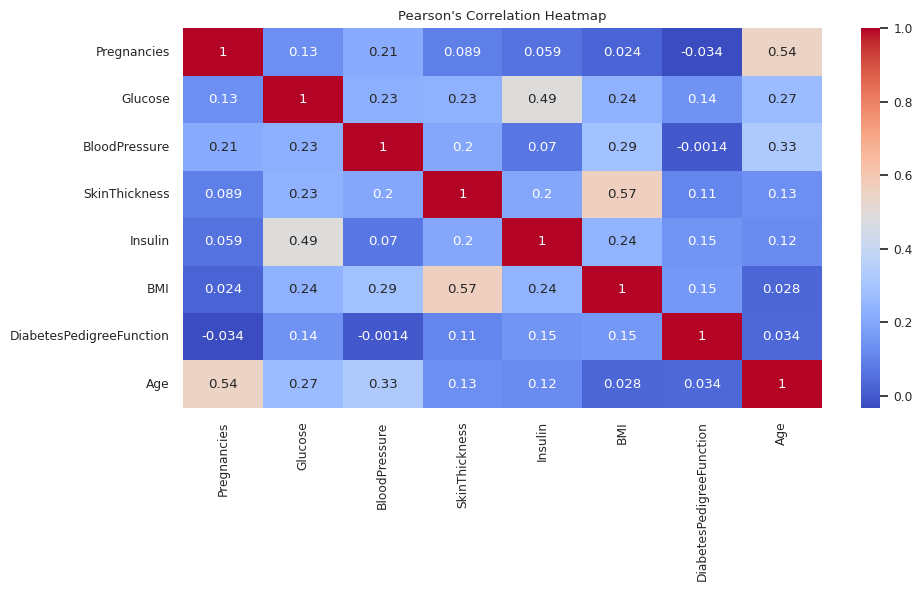

In [16]:
# @title **Pearson's correlation heatmap**

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Pearson's Correlation Heatmap")
plt.tight_layout()
plt.show()

In [17]:
# @title **Spearman's Rank correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr(method='spearman')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.132303,0.188271,0.104164,0.144205,0.003712,-0.043242,0.607216,0.198689
Glucose,0.132303,1.000000,0.254123,0.257363,0.566551,0.232325,0.092499,0.285721,0.485358
BloodPressure,0.188271,0.254123,1.000000,0.220772,0.143892,0.299263,0.011962,0.367451,0.186925
SkinThickness,0.104164,0.257363,0.220772,1.000000,0.318321,0.586358,0.066185,0.195109,0.358751
Insulin,0.144205,0.566551,0.143892,0.318321,1.000000,0.305860,0.134986,0.241295,0.562991
BMI,0.003712,0.232325,0.299263,0.586358,0.305860,1.000000,0.134768,0.125020,0.312524
DiabetesPedigreeFunction,-0.043242,0.092499,0.011962,0.066185,0.134986,0.134768,1.000000,0.042909,0.175353
Age,0.607216,0.285721,0.367451,0.195109,0.241295,0.125020,0.042909,1.000000,0.309040
Outcome,0.198689,0.485358,0.186925,0.358751,0.562991,0.312524,0.175353,0.309040,1.000000


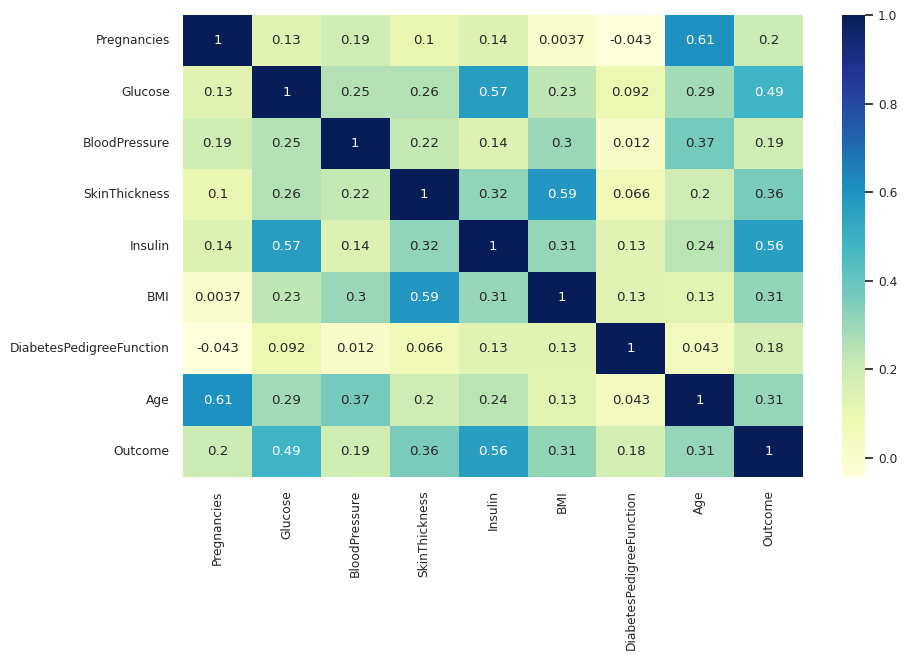

In [18]:
# @title **Spearman's Rank correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.corr(method='spearman'), annot=True, cmap="YlGnBu");

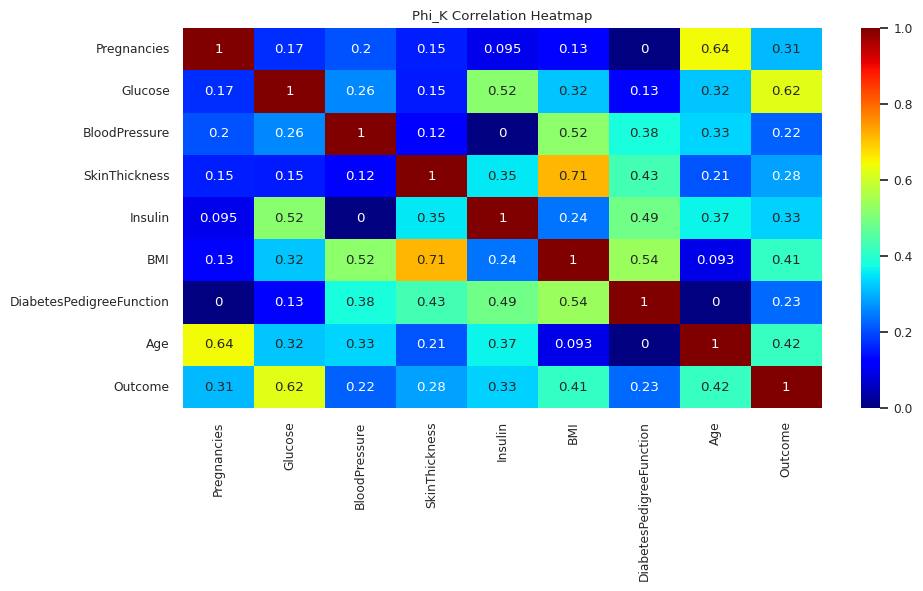

In [19]:
# @title **Phi-K correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

import os
import sys
import subprocess

# Suppress pip install output
subprocess.run([sys.executable, "-m", "pip", "install", "phik"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import phik
from phik import resources, report
from phik.report import plot_correlation_matrix
from phik import phik_matrix

# Identify interval (numerical) columns
interval_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create correlation map using Phi-K
plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

# Compute and plot Phi-K correlation matrix with interval columns specified
phik_corr = df.phik_matrix(interval_cols=interval_cols)
sns.heatmap(phik_corr, annot=True, cmap="jet")

plt.title("Phi_K Correlation Heatmap")
plt.tight_layout()
plt.show()

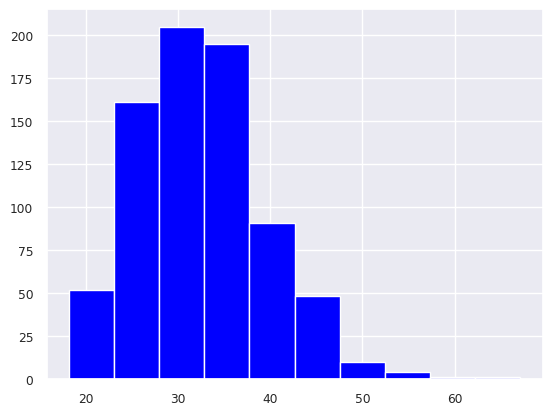

In [20]:
# @title **Example of a histogram**
plt.hist(df['BMI'], color='blue'); # CHANGE VARIABLE HERE

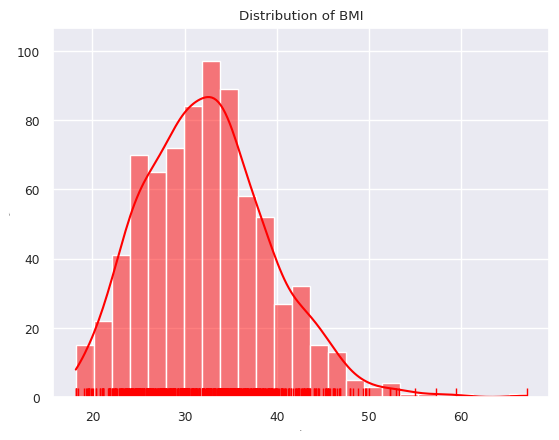

In [21]:
# @title **Example of a distribution plot**

import seaborn as sns
import matplotlib.pyplot as plt

variable = "BMI"

sns.histplot(data=df, x=variable, color="red", kde=True)
sns.rugplot(data=df, x=variable, color="red")

plt.title(f"Distribution of {variable}")
plt.show()

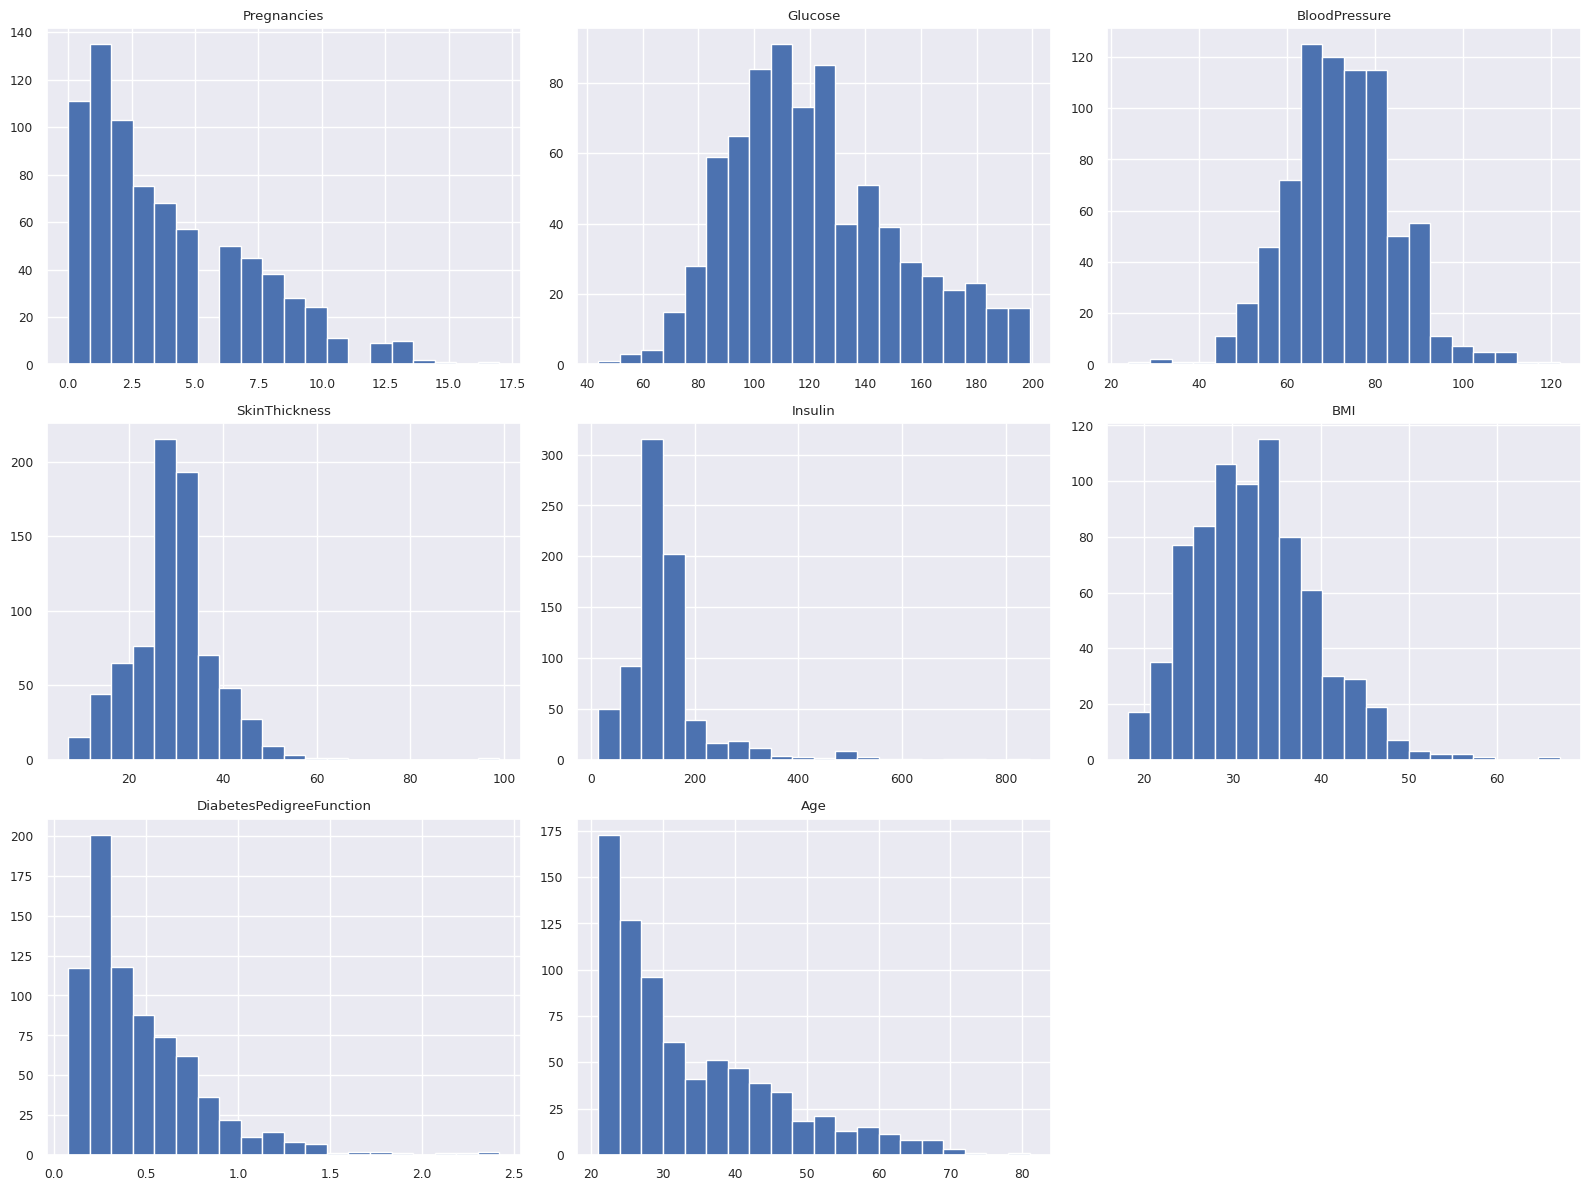

In [22]:
# @title **Generate histograms for all numerical variables**
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

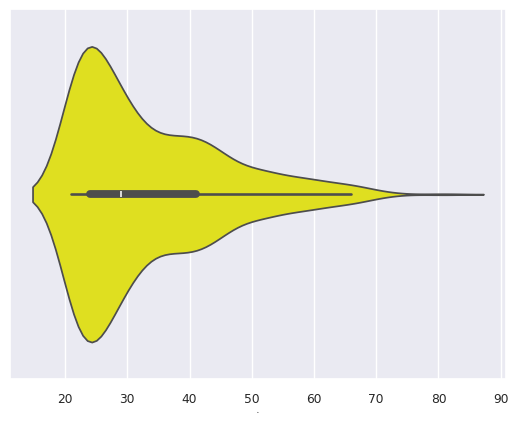

In [23]:
# @title **Example of a violin plot**
sns.violinplot(df['Age'], color='yellow', orient='h'); # CHANGE VARIABLE AND COLOR HERE

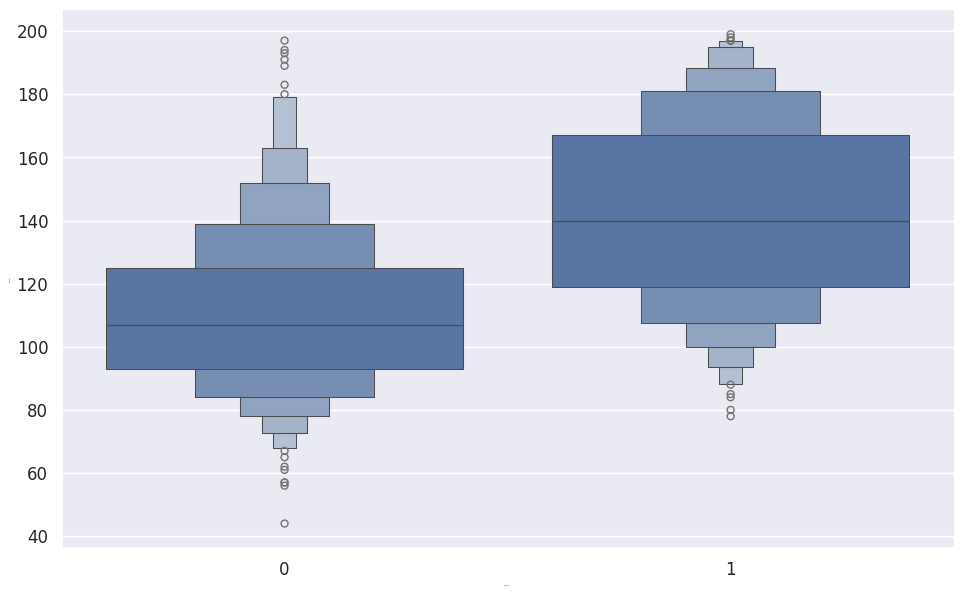

In [24]:
# @title **Example of categorical plot**
# Define the plot variables
x_var = "Outcome"
y_var = "Glucose"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the plot
g = sns.catplot(x=x_var, y=y_var, data=df, kind='boxen', height=6, aspect=1.6, estimator=np.mean);

# Dynamically set axis labels
g.set_axis_labels(x_var, y_var)
g.set_titles("{col_name}")

# Optionally set font size
g.set(xlabel=x_var, ylabel=y_var)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [25]:
# @title **Define a function to create a boxplot and histogram combo**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
def histogram_boxplot(feature, figsize=(10,6), bins=None):
    """ Boxplot and histogram combined (horizontal boxplot version)
    feature: 1-d feature array
    figsize: size of fig (default (10,6))
    bins: number of bins (default None / auto)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from scipy.stats import norm

    sns.set(font_scale=1)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )

    # Horizontal boxplot
    sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color='red')

    # Histogram
    if bins:
        sns.histplot(feature, kde=False, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(feature, kde=False, ax=ax_hist2)

    # Add central tendency lines to histogram
    ax_hist2.axvline(np.mean(feature), color='black', linestyle='--', label='Mean')
    ax_hist2.axvline(np.median(feature), color='green', linestyle='-', label='Median')
    ax_hist2.axvline(feature.mode()[0], color='red', linestyle='dashed', linewidth=1, label='Mode')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

print("Function successfully created")

Function successfully created


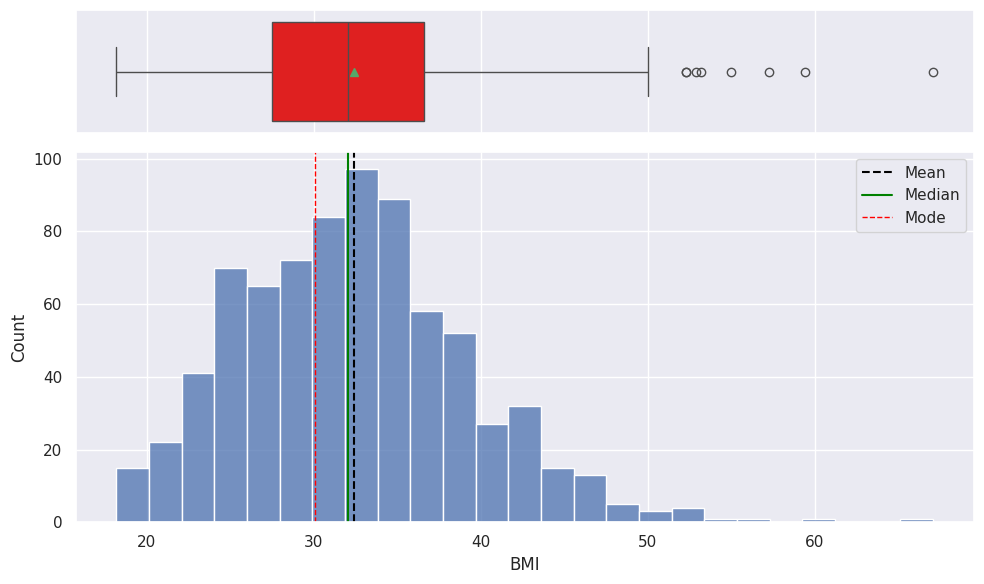

In [26]:
# @title **Example of a combination boxplot and histogram**

histogram_boxplot(df.BMI) # CHANGE THE CONTINUOUS VARIABLE HERE

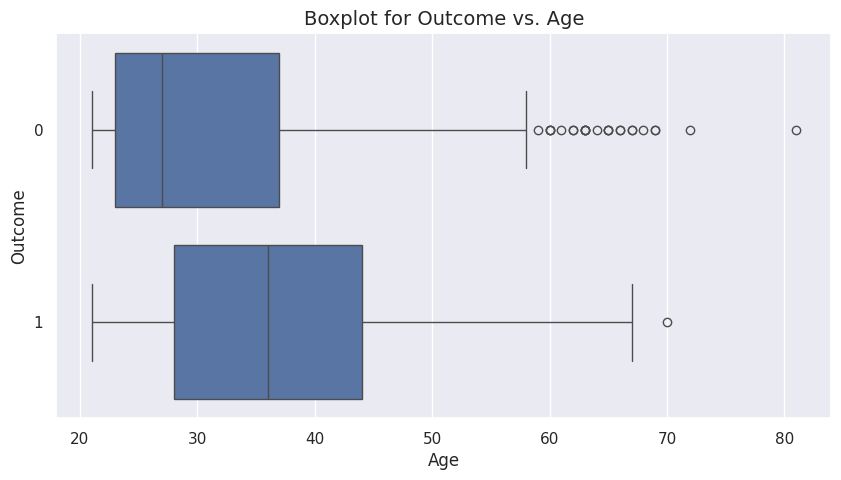

In [27]:
# @title **Example of boxplot with the primary outcome and a continuous variable**

# Define variables
x_var = "Age" # CHANGE VARIABLE HERE
y_var = "Outcome"  # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=x_var, y=y_var, data=df)

# Dynamic labels and title
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'Boxplot for {y_var} vs. {x_var}', fontsize=14)

plt.show()

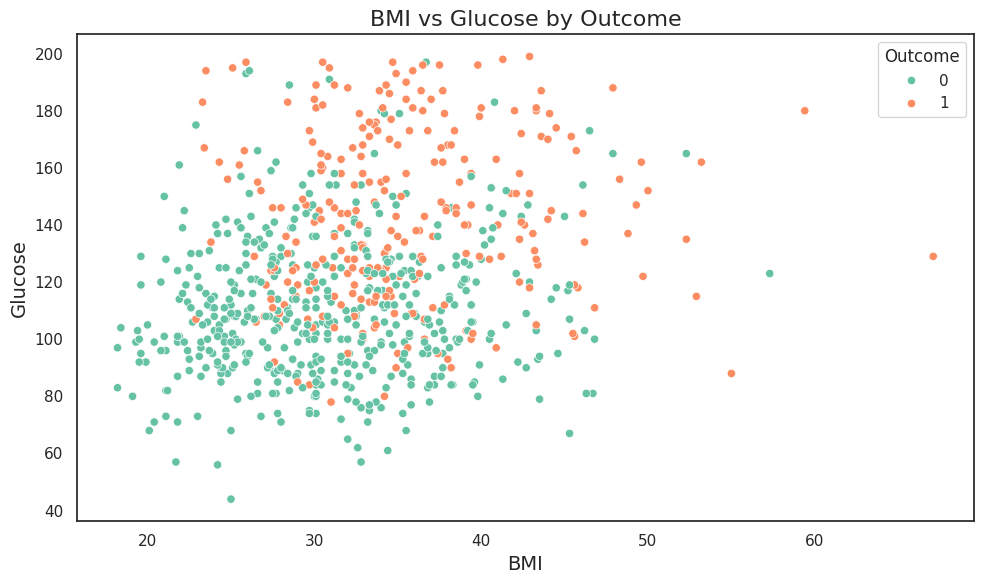

In [28]:
# @title **Example of a scatterplot**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the scatterplot
sns.set(style="white")  # Clean background without gridlines
plt.figure(figsize=(10, 6))

# Scatterplot
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df, palette='Set2')

# Add title and axis labels
plt.title('BMI vs Glucose by Outcome', fontsize=16)
plt.xlabel('BMI', fontsize=14)
plt.ylabel('Glucose', fontsize=14)

# Remove gridlines
plt.grid(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

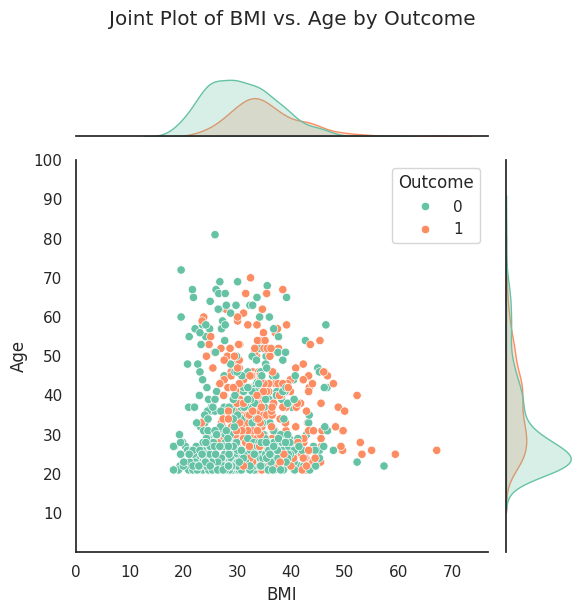

In [29]:
# @title **Example of a joint plot (3 variables)**
g = sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE
    hue='Outcome',
    data=df,
    palette='Set2',
    height=6,
)

# Set x-axis and y-axis limits
g.ax_joint.set_xlim(left=0)
g.ax_joint.set_ylim(bottom=0)

# Set y-axis ticks to increase by 10
y_min, y_max = g.ax_joint.get_ylim()
g.ax_joint.set_yticks(np.arange(10, y_max + 10, 10))

# Add title
plt.suptitle("Joint Plot of BMI vs. Age by Outcome", y=1.02)
plt.tight_layout()
plt.show()

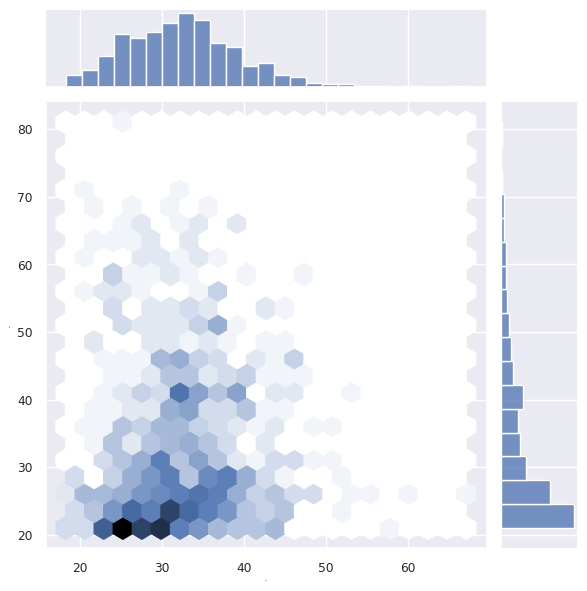

In [30]:
# @title **Example of a joint plot of a different kind (2 variables)**

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='hex',
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

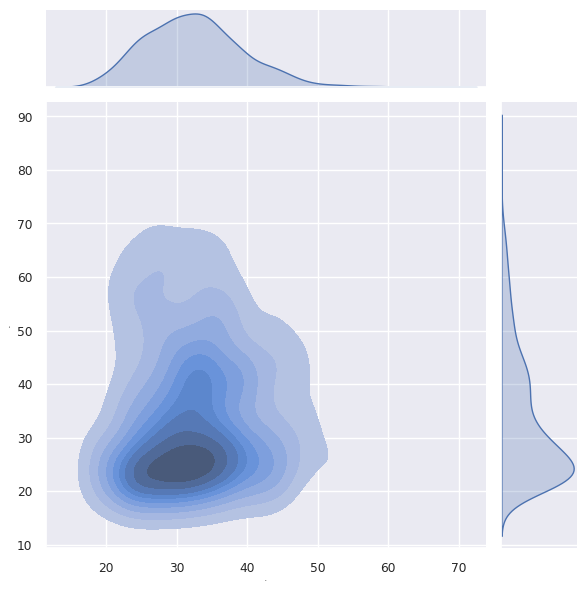

In [31]:
# @title **Another example of a joint plot of a different kind (2 variables)**
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='kde',
    fill = True,
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

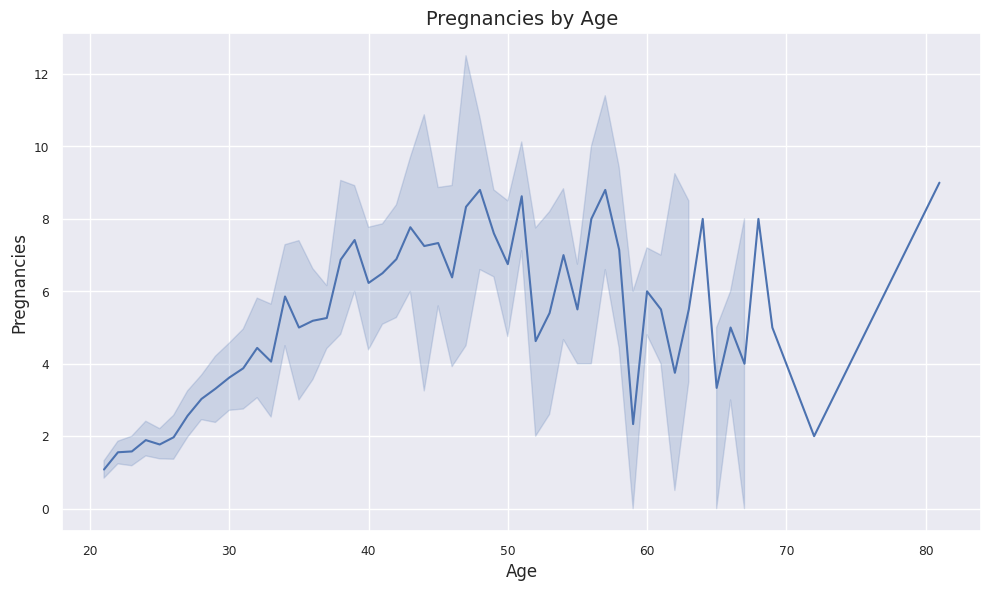

In [32]:
# @title **Example of a line plot**

# Define x and y columns
x_col = 'Age' # CHANGE VARIABLE HERE
y_col = 'Pregnancies' # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Set up figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create lineplot
sns.lineplot(x=x_col, y=y_col, data=df, ax=ax)

# Set axis labels and title explicitly
ax.set_xlabel(x_col, fontsize=12)
ax.set_ylabel(y_col, fontsize=12)
ax.set_title(f'{y_col} by {x_col}', fontsize=14)

# Ensure labels are not cut off
plt.tight_layout()

# Show the plot
plt.show()

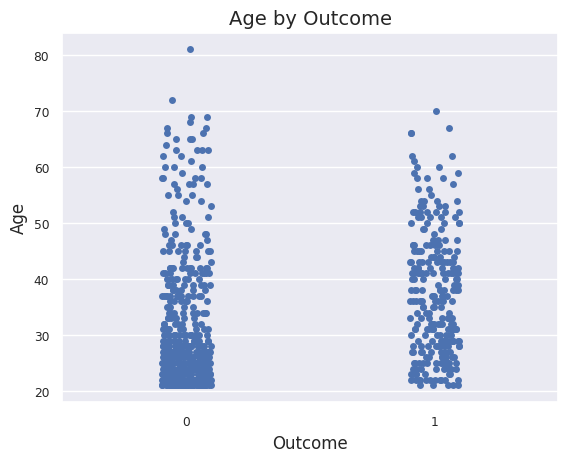

In [33]:
# @title **Example of a strip plot**

# Define axis variables
x_var = "Outcome"  # CHANGE VARIABLE HERE
y_var = "Age"      # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
sns.stripplot(data=df, x=x_var, y=y_var, jitter=True)
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

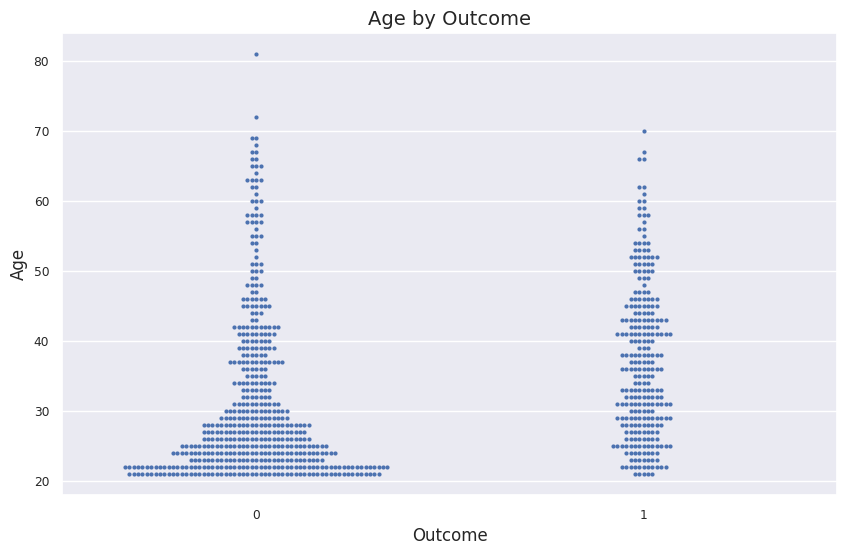

In [34]:
# @title **Example of a swarm plot**

x_var = "Outcome"
y_var = "Age"

plt.figure(figsize=(10, 6))
sns.swarmplot(data=df, x=x_var, y=y_var, size=3)

plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

**Link to other data visualizations: https://seaborn.pydata.org/examples/index.html**

,People,% with diabetes
Group,,
Underweight,4,0.0
Normal,102,6.9
Overweight,179,22.3
Obese,483,45.8


Trend: the diabetes rate rises (or stays level) with every group.


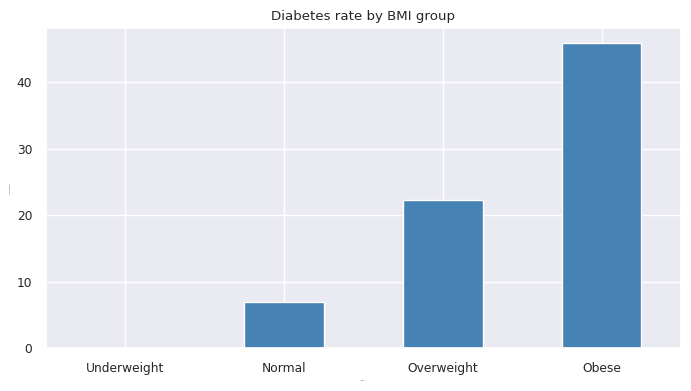

In [35]:
# @title **C. Automatic risk groups and diabetes rates**
import matplotlib.pyplot as plt

GROUP_VARIABLE = "BMI"    # choose "BMI", "Age", or "Glucose"
small_group_size = 30     # warn if a group has fewer people than this

#3 small functions, each turning a number into a group label
def bmi_group(value):
    if pd.isna(value):
        return "Unknown"
    elif value < 18.5:
        return "Underweight"
    elif value < 25:
        return "Normal"
    elif value < 30:
        return "Overweight"
    else:
        return "Obese"

def age_group(value):
    if pd.isna(value):
        return "Unknown"
    elif value < 30:
        return "21-29"
    elif value < 40:
        return "30-39"
    elif value < 50:
        return "40-49"
    else:
        return "50+"

def glucose_group(value):
    #Cutoffs for a 2-hour glucose tolerance test
    if pd.isna(value):
        return "Unknown"
    elif value < 140:
        return "Normal (<140)"
    elif value < 200:
        return "Elevated (140-199)"
    else:
        return "Very high (200+)"

#Dictionary: variable name -> (function to use, display order of groups)
rules = {
    "BMI": (bmi_group, ["Underweight", "Normal", "Overweight", "Obese"]),
    "Age": (age_group, ["21-29", "30-39", "40-49", "50+"]),
    "Glucose": (glucose_group, ["Normal (<140)", "Elevated (140-199)", "Very high (200+)"]),
}

#Decision: is the chosen variable supported?
if GROUP_VARIABLE not in rules:
    print(f"'{GROUP_VARIABLE}' is not supported. Choose from: {list(rules.keys())}")
else:
    group_function, order = rules[GROUP_VARIABLE]

    temp = df.copy()
    temp["Group"] = temp[GROUP_VARIABLE].apply(group_function)
    temp["Has_Diabetes"] = temp["Outcome"].astype(int)

    table = temp.groupby("Group")["Has_Diabetes"].agg(["count", "mean"])
    table["mean"] = (table["mean"] * 100).round(1)
    table.columns = ["People", "% with diabetes"]
    table = table.reindex([g for g in order if g in table.index])
    display(table)

    #Warn about small groups
    for group_name, row in table.iterrows():
        if row["People"] < small_group_size:
            print(f"Warning: '{group_name}' has only {int(row['People'])} people; "
                  "its percentage may be unreliable.")
#MODIFIED: new conditional logic - describe the trend automatically
    rates = list(table["% with diabetes"])
    if all(rates[i] <= rates[i + 1] for i in range(len(rates) - 1)):
        print("Trend: the diabetes rate rises (or stays level) with every group.")
    elif all(rates[i] >= rates[i + 1] for i in range(len(rates) - 1)):
        print("Trend: the diabetes rate falls with every group.")
    else:
        print("Trend: the diabetes rate does not move in one consistent direction.")

    #Bar chart
    table["% with diabetes"].plot(kind="bar", color="steelblue", figsize=(7, 4))
    plt.ylabel("% with diabetes")
    plt.title(f"Diabetes rate by {GROUP_VARIABLE} group")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


###C.  Purpose
Turns a continuous variable (BMI, Age, or Glucose) into labeled groups, then calculates what percentage of each group has diabetes. The user picks the variable, and the code automatically uses the matching grouping function.

### Settings the user can change
| Setting | Meaning |
|---|---|
| `GROUP_VARIABLE` | Which variable to group: "BMI", "Age", or "Glucose" |
| `small_group_size` | A group with fewer people than this triggers a warning |

### User-defined functions (written with `def`)
Each function takes one number (`value`) and returns a text label. They use `if / elif / else`, and the first True condition wins.

| Function | Groups it creates | Cutoffs |
|---|---|---|
| `bmi_group(value)` | Underweight, Normal, Overweight, Obese | <18.5, 18.5-24.9, 25-29.9, 30+ (standard BMI categories) |
| `age_group(value)` | 21-29, 30-39, 40-49, 50+ | Decade-based age bands |
| `glucose_group(value)` | Normal, Elevated, Very high | <140, 140-199, 200+ (2-hour glucose tolerance test cutoffs) |

Every function begins with `if pd.isna(value): return "Unknown"` so that a missing value gets its own label instead of causing an error.

### Other functions and commands used
| Code | What it does |
|---|---|
| `rules = {...}` | A **dictionary** linking each variable name to its grouping function and display order |
| `if GROUP_VARIABLE not in rules` | Checks that the chosen variable is supported; otherwise prints an error message |
| `df.copy()` | Makes a copy so the original `df` is not changed |
| `.apply(group_function)` | Runs the chosen function on every value in the column |
| `.astype(int)` | Converts `Outcome` to integers (it may have been changed to a category earlier) so that averages work |
| `groupby("Group")` | Splits the rows into groups |
| `.agg(["count", "mean"])` | Calculates the group size and the mean of `Has_Diabetes` |
| mean of 0/1 × 100 | The average of a 0/1 variable is the proportion with diabetes, shown as a percentage |
| `.reindex([...])` | Puts the groups in logical order (e.g., Underweight before Obese) |
| `.iterrows()` | Loops through the table row by row to check for small groups |
| `.plot(kind="bar")` | Draws the bar chart |

### Decision logic
1. Is `GROUP_VARIABLE` supported? If not, stop with a message.
2. Which function should be used? The dictionary looks it up automatically.
3. Is any group smaller than `small_group_size`? If so, print a warning that its percentage may be unreliable.

### Output
A table (People, % with diabetes) for each group, any small-group warnings, and a bar chart.

### What to look for
- Does the diabetes rate rise from one group to the next?
- Which group is largest or smallest? Did a warning appear?
- Run the block three times with different `GROUP_VARIABLE` values and compare.
- These are descriptive associations, not proof that one factor causes diabetes.

In [36]:
# @title **D. Automatic outlier check (IQR rule)**
import math

REPORT_MODE = "summary"    #"summary" = table only, "detail" = table + boxplots + extreme values
outlier_limit = 5          #flag a variable if more than 5% of its values are outliers
multiplier = 3.0           #MODIFIED (FROM 1.5) -------------------------------

if REPORT_MODE not in ["summary", "detail"]:
    print("REPORT_MODE must be 'summary' or 'detail'.")
else:
    numeric_cols = df.select_dtypes(include="number").columns
    rows = []

    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr

        is_outlier = (df[col] < lower) | (df[col] > upper)
        n_outliers = is_outlier.sum()
        pct = n_outliers / df[col].notna().sum() * 100

        if pct > outlier_limit:
            decision = "REVIEW: many outliers"
        elif n_outliers > 0:
            decision = "Some outliers"
        else:
            decision = "No outliers"

        rows.append({"Variable": col, "Lower fence": round(lower, 2),
                     "Upper fence": round(upper, 2), "Outliers": n_outliers,
                     "% Outliers": round(pct, 1), "Decision": decision})

        #Extra output only in detail mode
        if REPORT_MODE == "detail" and n_outliers > 0:
            print(f"{col}: smallest outlier = {df.loc[is_outlier, col].min()}, "
                  f"largest outlier = {df.loc[is_outlier, col].max()}")

    display(pd.DataFrame(rows))

    if REPORT_MODE == "detail":
        n_cols = 4
        n_rows = math.ceil(len(numeric_cols) / n_cols)
        df[numeric_cols].plot(kind="box", subplots=True, layout=(n_rows, n_cols),
                              figsize=(14, 3.5 * n_rows))
        plt.tight_layout()
        plt.show()
    else:
        print("Change REPORT_MODE to 'detail' to see boxplots and extreme values.")

,Variable,Lower fence,Upper fence,Outliers,% Outliers,Decision
0,Pregnancies,-14.00,21.00,0,0.0,No outliers
1,Glucose,-21.75,261.75,0,0.0,No outliers
2,BloodPressure,16.00,128.00,0,0.0,No outliers
3,SkinThickness,4.00,53.00,6,0.8,Some outliers
4,Insulin,-98.50,370.50,23,3.0,Some outliers
5,BMI,0.20,63.90,1,0.1,Some outliers
6,DiabetesPedigreeFunction,-0.90,1.77,6,0.8,Some outliers
7,Age,-27.00,92.00,0,0.0,No outliers


Change REPORT_MODE to 'detail' to see boxplots and extreme values.



###D.  Purpose
Finds unusually high or low values in every numeric column using the IQR rule, flags variables with many outliers, and lets the user choose how much detail to display.

### Settings the user can change
| Setting | Meaning |
|---|---|
| `REPORT_MODE` | `"summary"` shows the table only; `"detail"` also shows extreme values and boxplots |
| `outlier_limit` | A variable is flagged for review if more than this percentage of its values are outliers |
| `multiplier` | 1.5 is the standard IQR rule; 3 finds only extreme outliers |

### The IQR rule
- **Q1** = 25th percentile, **Q3** = 75th percentile
- **IQR** = Q3 − Q1 (the spread of the middle 50% of the data)
- **Lower fence** = Q1 − multiplier × IQR
- **Upper fence** = Q3 + multiplier × IQR
- Any value outside the fences is an outlier.

### Functions and commands used
| Code | What it does |
|---|---|
| `df.select_dtypes(include="number").columns` | Automatically finds the numeric columns |
| `.quantile(0.25)` / `.quantile(0.75)` | Calculates Q1 and Q3 |
| `(df[col] < lower) \| (df[col] > upper)` | Marks each value True if it is below the lower fence **or** above the upper fence |
| `.sum()` on True/False values | Counts the True values, i.e., the outliers |
| `.notna().sum()` | Counts non-missing values, used as the denominator for the percentage |
| `df.loc[is_outlier, col].min()` / `.max()` | Selects only the outlier values and finds the smallest and largest |
| `rows.append({...})` | Adds one result row per variable to a list |
| `pd.DataFrame(rows)` | Turns the list into a table |
| `math.ceil()` | Rounds up, so the boxplot grid has enough rows |
| `.plot(kind="box", subplots=True, layout=(...))` | Draws one boxplot per variable in a grid |
| `plt.tight_layout()` / `plt.show()` | Prevents overlapping labels and displays the figure |

### Decision logic
1. **Is `REPORT_MODE` valid?** If not, print an error message and stop.
2. **For each variable:**
   - Outlier percentage above `outlier_limit` → **REVIEW: many outliers**
   - Some outliers but below the limit → **Some outliers**
   - None → **No outliers**
3. **Detail mode only:** print the smallest and largest outlier for each variable and draw the boxplots. In summary mode the code prints a reminder of how to switch.

### Output
A table (fences, outlier count, % outliers, decision) and, in detail mode, extreme values and boxplots.

### What to look for
- Which variables have the most outliers?
- Are they plausible or likely errors? A BMI of 67 is extreme but possible. A very large Insulin value should be checked.
- If `Outcome` was converted to a category earlier, it is not numeric and so is excluded from this check.
- An outlier is not automatically an error. It is a flag for review, and no values were removed or changed.

## **Inferential Statistics**

In [37]:
# @title **Import additional inferential statistics libraries**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
import math
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind

print("Libraries successfully imported.")

Libraries successfully imported.


In [38]:
# @title **Example of a one-sample t-test**

from scipy.stats import ttest_1samp

variable = "BMI"       # CHANGE VARIABLE HERE
threshold = 30        # CHANGE REFERENCE VALUE HERE
alpha = 0.05          # CHANGE SIGNIFICANCE LEVEL HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing observations.
values = df[variable].dropna()

if len(values) < 2 or values.std() == 0:
    raise ValueError(
        "The test requires at least two nonmissing values and nonzero variance."
    )

# Perform a two-sided one-sample t-test.
t_statistic, p_value = ttest_1samp(values, popmean=threshold)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"is {direction} than {threshold}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence that the population mean "
        f"{variable} differs from {threshold}."
    )

print(f"Null hypothesis: The population mean {variable} equals {threshold}.")
print(f"Alternative hypothesis: The population mean {variable} differs from {threshold}.")
print(f"\nNonmissing observations: {len(values)}")
print(f"Sample mean: {values.mean():.3f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean BMI equals 30.
Alternative hypothesis: The population mean BMI differs from 30.

Nonmissing observations: 768
Sample mean: 32.435
t-statistic: 9.806
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean BMI is higher than 30.


In [39]:
# @title **Independent samples t-test (specific to this dataset)**

from scipy.stats import ttest_ind

variable = "BMI"
group_col = "Outcome"
alpha = 0.05

label_map = {0: "Patients without diabetes", 1: "Patients with diabetes"}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing either the measurement or group.
test_data = df[[variable, group_col]].dropna()

if set(test_data[group_col].unique()) != {0, 1}:
    raise ValueError("The group variable must contain both groups, coded 0 and 1.")

# Set a consistent comparison order.
group1 = test_data.loc[test_data[group_col] == 0, variable]
group2 = test_data.loc[test_data[group_col] == 1, variable]

if len(group1) < 2 or len(group2) < 2:
    raise ValueError("Each group requires at least two nonmissing observations.")

if group1.var() == 0 and group2.var() == 0:
    raise ValueError("The test requires variation in at least one group.")

group1_name = label_map[0]
group2_name = label_map[1]

# Two-sided Welch's t-test.
t_statistic, p_value = ttest_ind(group1, group2, equal_var=False)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"for {group1_name.lower()} is {direction} than "
        f"for {group2_name.lower()}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference in population "
        f"mean {variable} between the two groups."
    )

print(f"Null hypothesis: The population mean {variable} is equal between groups.")
print(f"Alternative hypothesis: The population mean {variable} differs between groups.")

print(f"\n{group1_name}: n = {len(group1)}, mean = {group1.mean():.3f}")
print(f"{group2_name}: n = {len(group2)}, mean = {group2.mean():.3f}")
print(f"Mean difference (group 0 − group 1): {group1.mean() - group2.mean():.3f}")

print(f"\nWelch's independent samples t-test:")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean BMI is equal between groups.
Alternative hypothesis: The population mean BMI differs between groups.

Patients without diabetes: n = 500, mean = 30.846
Patients with diabetes: n = 268, mean = 35.399
Mean difference (group 0 − group 1): -4.553

Welch's independent samples t-test:
t-statistic: -9.167
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean BMI for patients without diabetes is lower than for patients with diabetes.


In [40]:
# @title **One-way ANOVA (specific to this dataset)**

import statsmodels.api as sm
from statsmodels.formula.api import ols

variable = "Glucose"
group_col = "Outcome"
alpha = 0.05

label_map = {
    0: "Patients without diabetes",
    1: "Patients with diabetes"
}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing the measurement or group.
test_data = df[[variable, group_col]].dropna().copy()

# Use standard column names for the model formula.
test_data.columns = ["measurement", "group"]
test_data["group"] = test_data["group"].astype("category")
test_data["group"] = test_data["group"].cat.remove_unused_categories()

group_summary = (
    test_data.groupby("group", observed=True)["measurement"]
    .agg(["count", "mean", "std"])
)

if len(group_summary) < 2:
    raise ValueError("ANOVA requires at least two groups.")

if (group_summary["count"] < 2).any():
    raise ValueError("Each group requires at least two nonmissing observations.")

if (group_summary["std"] == 0).all():
    raise ValueError("The test requires variation within at least one group.")

# Fit the model and calculate the ANOVA table.
anova_model = ols("measurement ~ C(group)", data=test_data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

f_stat = anova_table.loc["C(group)", "F"]
p_value = anova_table.loc["C(group)", "PR(>F)"]

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    interpretation = (
        f"There is evidence that at least two groups differ "
        f"in population mean {variable}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference "
        f"in population mean {variable} across groups."
    )

# Apply readable group labels for display.
group_summary.index = [
    label_map.get(group, str(group))
    for group in group_summary.index
]

print(f"Null hypothesis: Population mean {variable} is equal across all groups.")
print(f"Alternative hypothesis: At least one population mean differs.")

print("\nGroup summaries:")
display(group_summary.round(3))

print("\nANOVA table:")
display(anova_table.round(3))

print(f"\nF-statistic: {f_stat:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: Population mean Glucose is equal across all groups.
Alternative hypothesis: At least one population mean differs.

Group summaries:


,count,mean,std
Patients without diabetes,500,110.622,24.704
Patients with diabetes,268,142.302,29.489



ANOVA table:


,sum_sq,df,F,PR(>F)
C(group),175113.840,1.0,249.924,0.0
Residual,536712.077,766.0,NaN,NaN



F-statistic: 249.924
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that at least two groups differ in population mean Glucose.


In [41]:
# @title **Chi-square test of independence (specific to this dataset)**

import pandas as pd
from scipy.stats import chi2_contingency

group_col = "Outcome"
variable = "Pregnancies"
threshold = 6 #MODIFIED-----------------------------------------------------
alpha = 0.05

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing values before creating categories.
test_data = df[[group_col, variable]].dropna().copy()
test_data["Above threshold"] = test_data[variable] > threshold

crosstab = pd.crosstab(
    test_data[group_col],
    test_data["Above threshold"]
)

if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
    raise ValueError("The test requires at least two observed categories per variable.")

# Run Pearson's chi-square test without continuity correction.
chi2_stat, p_value, dof, expected = chi2_contingency(
    crosstab, correction=False
)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

print("Observed counts (False = ≤ threshold; True = > threshold):")
display(crosstab)

print("\nExpected counts under independence:")
display(pd.DataFrame(
    expected,
    index=crosstab.index,
    columns=crosstab.columns
).round(3))

print(f"\nNull hypothesis: {group_col} and {variable} > {threshold} are independent.")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p {formatted_p}")

if (expected < 5).any():
    print(
        "\nSmall expected counts detected. For this 2×2 table, "
        "consider Fisher's exact test before interpreting the chi-square result."
    )

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print(
        f"Interpretation: There is evidence of an association between "
        f"{group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )
else:
    print("Decision: Fail to reject the null hypothesis.")
    print(
        f"Interpretation: There is insufficient evidence of an association "
        f"between {group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )

Observed counts (False = ≤ threshold; True = > threshold):


Above threshold,False,True
Outcome,,
0,426,74
1,173,95



Expected counts under independence:


Above threshold,False,True
Outcome,,
0,389.974,110.026
1,209.026,58.974



Null hypothesis: Outcome and Pregnancies > 6 are independent.
Chi-square statistic: 43.341
Degrees of freedom: 1
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence of an association between Outcome and having Pregnancies > 6, provided the test assumptions are met.


In [42]:
# @title **Encode outcome labels as 0 and 1 (if needed)**

target_variable = "Outcome"
label_map = {"No Diabetes": 0, "Diabetes": 1}

outcome = df[target_variable]
observed_values = set(outcome.dropna().unique())

if observed_values.issubset({0, 1}):
    print("Outcome is already coded as 0/1.")

elif observed_values.issubset(set(label_map)):
    df[target_variable] = outcome.map(label_map)
    print("Outcome labels converted to 0/1.")

else:
    raise ValueError(
        f"Unexpected outcome values: {observed_values}. "
        "Update label_map to match your dataset."
    )

display(df[target_variable].head(10))

Outcome is already coded as 0/1.


,Outcome
0,1
1,0
2,1
3,0
4,1
5,0
6,1
7,0
8,1
9,1


### How the machine learning section works

**Goal:** predict whether a patient has diabetes (Outcome = 1) from the 8 numeric predictors.

**Pipeline stages and the decisions the code makes**
| Stage | What happens | Conditional logic |
|---|---|---|
| Split | 70% training / 30% test, stratified so both sets keep the same share of diabetes cases; `random_state=42` makes it repeatable | Stops with an error if the outcome is not 0/1 or any predictor is non-numeric |
| Imputation | Missing values are filled with the **median learned from the training set only** and reused on the test set, which avoids data leakage | `SimpleImputer` does nothing if no values are missing |
| Scaling | `StandardScaler` puts predictors on a common scale | `if isinstance(classifier, LogisticRegression)` adds it only for logistic regression |
| Training | Each model is fitted on training data only | Tuning stops with an error if a class has fewer than 5 training cases |
| Evaluation | Both models are scored on the same unseen test set | none |

**Logistic regression:** combines the predictors into a probability between 0 and 1. Cases at or above a cutoff are predicted as diabetic. It is scaled because its coefficients and built-in regularization are sensitive to the units of each variable.

**Decision tree:** a flowchart of yes/no splits (for example "Glucose > 127?"). It compares values within one variable at a time, so it does not need scaling. `GridSearchCV` tried 72 parameter combinations (4 depths × 3 leaf sizes × 3 leaf-node limits × 2 class-weight options) with 5-fold cross-validation, scored by F1. It chose max_depth 6, max_leaf_nodes 15, min_samples_leaf 5 and no class weighting, with a mean CV F1 of 0.812. The best of 72 trials tends to be optimistic, so compare it with the test-set score.

**Metrics**
| Metric | Meaning |
|---|---|
| Accuracy | Share of all patients classified correctly |
| Recall (sensitivity) | Share of true diabetes cases the model catches |
| Precision | Share of predicted cases who truly have diabetes |
| F1 | Balance of precision and recall |
| ROC AUC | How well the model ranks cases above non-cases, regardless of cutoff (0.5 = chance, 1 = perfect) |
| Confusion matrix | Counts of true/false positives and negatives |

**Cutoff selection:** the cutoff (0.345) comes from training-set cross-validation by maximizing sensitivity + specificity − 1 (Youden's J). It is below 0.5, so the model flags more people as diabetic. That raises recall at the cost of more false alarms. It uses training data only, so the test set stays unseen.

**Limitations:** one dataset, one train/test split, and this is for instruction only, not clinical use.

## **Supervised Machine Learning (Binary Classification)**

**Two examples:**
- Logistic Regression  
- Decision Tree  

**LOGISTIC REGRESSION:** Additional Info on Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## **Logistic Regression**

In [43]:
# @title **Configure and split data for the automated ML pipeline**

from sklearn.model_selection import train_test_split

target_variable = "Outcome"  # CHANGE FOR YOUR DATASET

# Exclude rows with missing outcomes; do not impute the outcome.
ml_data = df.dropna(subset=[target_variable]).copy()

X = ml_data.drop(columns=[target_variable])
y = ml_data[target_variable]

# This demonstration expects numeric predictors and an outcome coded 0/1.
if set(y.unique()) != {0, 1}:
    raise ValueError("The outcome must contain both classes, coded 0 and 1.")

if not all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns):
    raise ValueError("This pipeline requires numeric predictors.")

y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Training observations: 537
Test observations: 231


In [44]:
# @title **Define a function to display a confusion matrix**

from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_actual, y_predict):
    """Display counts and percentages of all evaluated observations."""

    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])

    if cm.sum() == 0:
        raise ValueError("No observations with labels 0 or 1 to display.")

    cell_names = np.array([
        ["True negative", "False positive"],
        ["False negative", "True positive"]
    ])

    annotations = np.array([
        f"{name}\n{count}\n{count / cm.sum():.2%}"
        for name, count in zip(cell_names.flatten(), cm.flatten())
    ]).reshape(2, 2)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=annotations,
        fmt="",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

print("Function successfully created.")

Function successfully created.


In [45]:
# @title **Build logistic regression with automated preprocessing**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Learn imputation and scaling from training data only.
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

# Apply the fitted preprocessing and model to test data.
y_predict = logistic_pipeline.predict(X_test)
model_score = logistic_pipeline.score(X_test, y_test)

print(f"Test-set accuracy: {model_score:.2%}")
print(
    f"The model correctly classified {model_score:.2%} "
    "of observations in the test set."
)

Test-set accuracy: 74.89%
The model correctly classified 74.89% of observations in the test set.


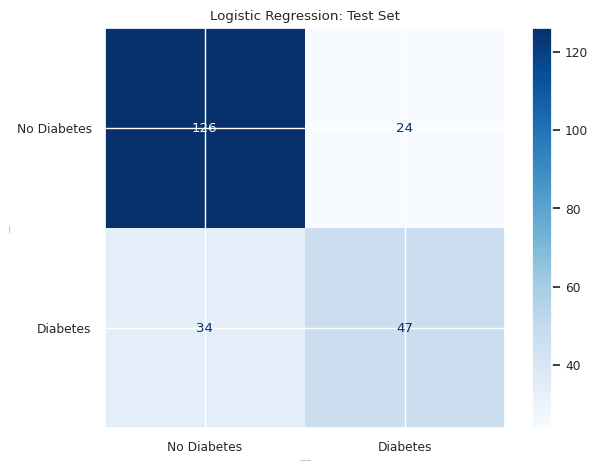

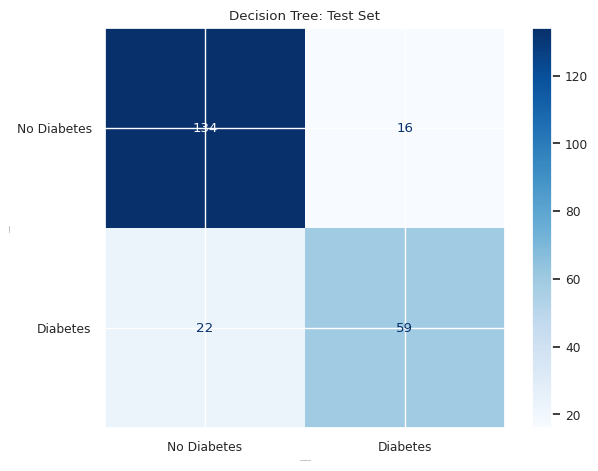

Test-set performance:


,Accuracy,Recall,Precision,F1,ROC AUC
Model,,,,,
Logistic Regression,0.749,0.580,0.662,0.618,0.855
Decision Tree,0.835,0.728,0.787,0.756,0.811


In [46]:
# @title **Automatically preprocess, train, and evaluate ML models**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Define the models to run automatically.
models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

trained_pipelines = {}
results = []

for model_name, classifier in models.items():

    # Preprocessing is fitted using training data only.
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Apply scaling when appropriate for the model.
    if isinstance(classifier, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", classifier))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    positive_index = list(pipeline.classes_).index(1)
    probabilities = pipeline.predict_proba(X_test)[:, positive_index]

    trained_pipelines[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["No Diabetes", "Diabetes"],
        cmap="Blues"
    )
    plt.title(f"{model_name}: Test Set")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).set_index("Model")

print("Test-set performance:")
display(results_df.round(3))

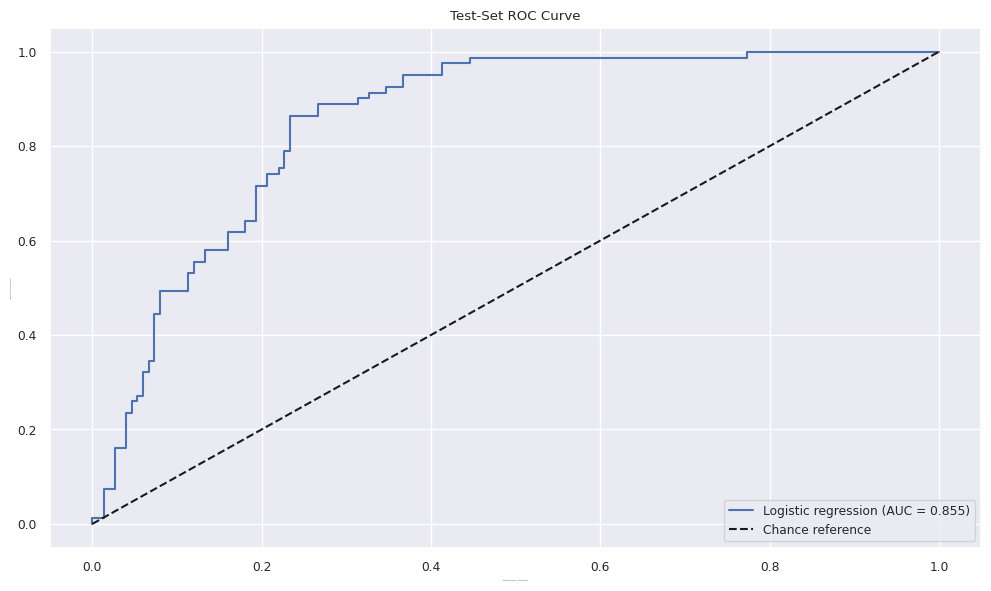

Test-set ROC AUC: 0.855


In [47]:
# @title **ROC curve and AUC for logistic regression**

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the positive class (1).
positive_index = list(logistic_pipeline.classes_).index(1)
y_probability = logistic_pipeline.predict_proba(X_test)[:, positive_index]

# Calculate test-set ROC AUC and curve.
logit_roc_auc = roc_auc_score(y_test, y_probability)
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {logit_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance reference")
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Test-Set ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Test-set ROC AUC: {logit_roc_auc:.3f}")

In [48]:
# @title **Select a cutoff using training-set cross-validation**

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Use the logistic_pipeline defined in the training block.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

# Each observation is predicted by a pipeline trained on other folds.
# Imputation and scaling are learned separately within each fold.
cv_probabilities = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)

positive_index = list(logistic_pipeline.classes_).index(1)

fpr, tpr, thresholds = roc_curve(
    y_train,
    cv_probabilities[:, positive_index]
)

# Exclude the infinite threshold representing no positive predictions.
finite = np.isfinite(thresholds)
j_scores = tpr[finite] - fpr[finite]
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[finite][optimal_idx]

print(f"Selected threshold: {optimal_threshold:.3f}")
print("Criterion: maximum cross-validation sensitivity + specificity − 1.")
print("Apply this cutoff to the fitted pipeline's test-set probabilities.")

Selected threshold: 0.345
Criterion: maximum cross-validation sensitivity + specificity − 1.
Apply this cutoff to the fitted pipeline's test-set probabilities.


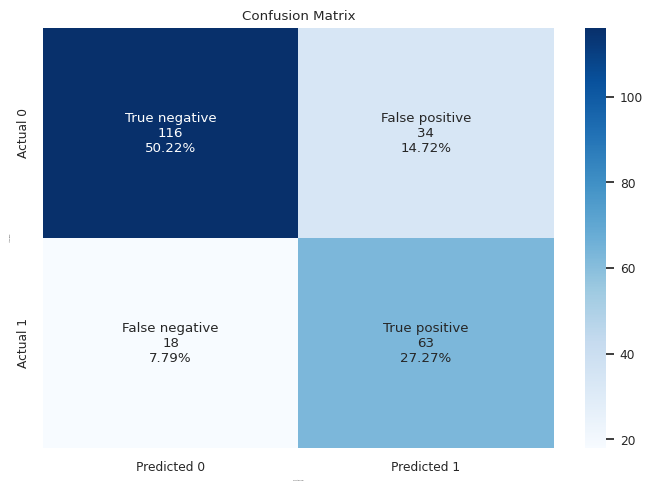

In [49]:
# @title **Make confusion matrix using the selected cutoff**

positive_index = list(logistic_pipeline.classes_).index(1)

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

make_confusion_matrix(y_test, y_pred_ts)

In [50]:
# @title **Compare training and test F1 at the selected cutoff**

from sklearn.metrics import f1_score

positive_index = list(logistic_pipeline.classes_).index(1)

train_probabilities = logistic_pipeline.predict_proba(
    X_train
)[:, positive_index]

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_tr = (train_probabilities >= optimal_threshold).astype(int)
y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

print(f"Selected cutoff: {optimal_threshold:.3f}")
print(f"Training F1: {f1_score(y_train, y_pred_tr, zero_division=0):.3f}")
print(f"Test F1: {f1_score(y_test, y_pred_ts, zero_division=0):.3f}")

Selected cutoff: 0.345
Training F1: 0.732
Test F1: 0.708


## **Decision Tree**

**DECISION TREE: https://scikit-learn.org/stable/modules/tree.html#**

In [51]:
# @title **Import libraries for decision tree training and evaluation**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Decision tree libraries imported successfully.")

Decision tree libraries imported successfully.


In [52]:
# @title **Build and tune decision tree using cross-validation F1**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Choose the metric used for tuning.
scoring_metric = "f1"  # Alternatives: "recall", "precision", "accuracy"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

dtree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Pipeline parameters require the step name prefix.
parameters = {
    "classifier__max_depth": [2, 4, 6, 8],
    "classifier__min_samples_leaf": [5, 10, 15],
    "classifier__max_leaf_nodes": [5, 10, 15],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

grid_obj = GridSearchCV(
    estimator=dtree_pipeline,
    param_grid=parameters,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_obj.fit(X_train, y_train)

# Already refitted on the full training set; no additional fit is needed.
dtree = grid_obj.best_estimator_

print("Decision tree pipeline built and tuned.")
print(f"Best mean cross-validation {scoring_metric}: {grid_obj.best_score_:.3f}")
print("Selected parameters:")
print(grid_obj.best_params_)

Decision tree pipeline built and tuned.
Best mean cross-validation f1: 0.812
Selected parameters:
{'classifier__class_weight': None, 'classifier__max_depth': 6, 'classifier__max_leaf_nodes': 15, 'classifier__min_samples_leaf': 5}


In [53]:
# @title **Function to calculate accuracy, recall, precision, and F1**

from sklearn import metrics

def get_metrics_score(model, flag=True):
    """Evaluate a fitted classifier on the existing training and test sets."""

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = metrics.accuracy_score(y_train, pred_train)
    test_acc = metrics.accuracy_score(y_test, pred_test)

    train_recall = metrics.recall_score(
        y_train, pred_train, zero_division=0
    )
    test_recall = metrics.recall_score(
        y_test, pred_test, zero_division=0
    )

    train_precision = metrics.precision_score(
        y_train, pred_train, zero_division=0
    )
    test_precision = metrics.precision_score(
        y_test, pred_test, zero_division=0
    )

    train_f1 = metrics.f1_score(y_train, pred_train, zero_division=0)
    test_f1 = metrics.f1_score(y_test, pred_test, zero_division=0)

    score_list = [
        train_acc, test_acc,
        train_recall, test_recall,
        train_precision, test_precision,
        train_f1, test_f1
    ]

    if flag:
        print(f"{'Metric':<12} {'Training':>10} {'Test':>10}")
        for name, train_value, test_value in [
            ("Accuracy", train_acc, test_acc),
            ("Recall", train_recall, test_recall),
            ("Precision", train_precision, test_precision),
            ("F1", train_f1, test_f1)
        ]:
            print(f"{name:<12} {train_value:>10.3f} {test_value:>10.3f}")

    return score_list

print("Metric evaluation function successfully defined.")

Metric evaluation function successfully defined.


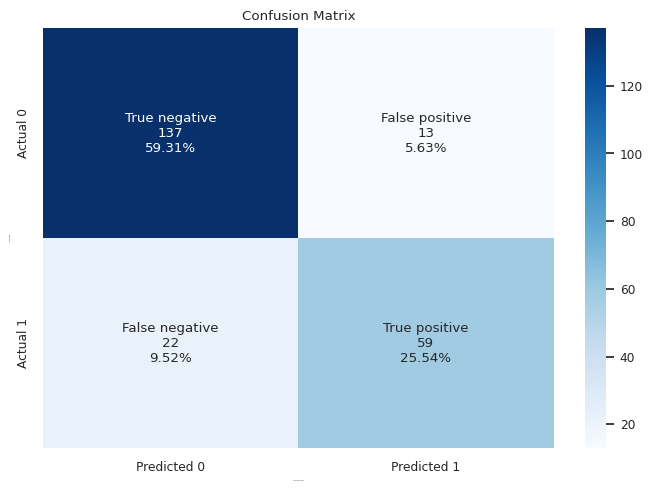

In [54]:
# @title **Display confusion matrix for the tuned decision tree**

y_pred_tree = dtree.predict(X_test)

make_confusion_matrix(y_test, y_pred_tree)

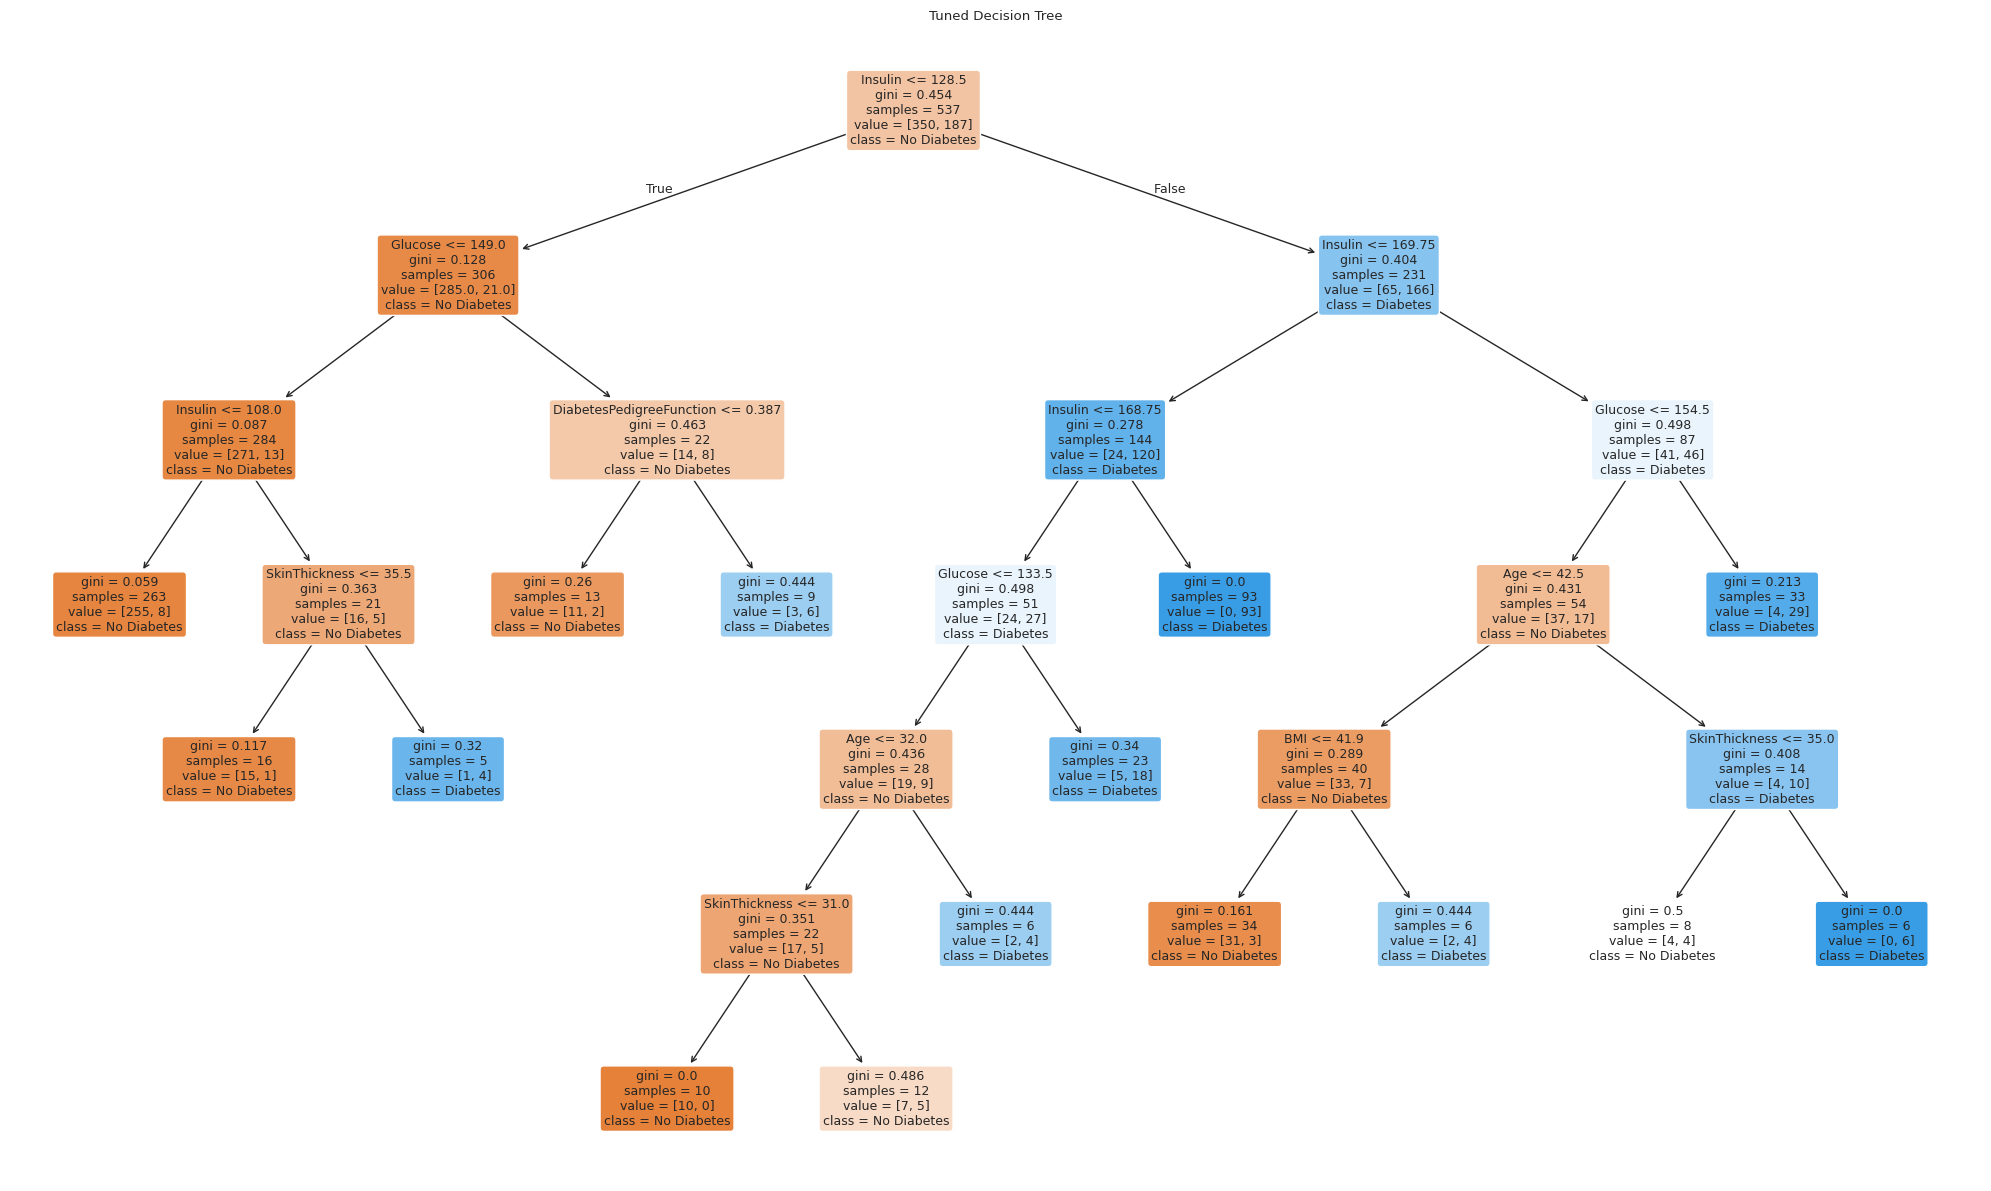

In [55]:
# @title **Show the tuned decision tree**

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

plt.figure(figsize=(20, 12))

plot_tree(
    tree_classifier,
    feature_names=list(feature_names),
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9,
    node_ids=False
)

plt.title("Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [56]:
# @title **List feature importance from the tuned decision tree**

import pandas as pd

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.reset_index(drop=True).round(3))

,Feature,Importance
0,Insulin,0.756
1,Glucose,0.124
2,Age,0.043
3,SkinThickness,0.043
4,BMI,0.019
5,DiabetesPedigreeFunction,0.015
6,BloodPressure,0.000
7,Pregnancies,0.000


In [57]:
#MODIFIED: call the existing function to compare training vs test performance
print("Logistic regression (default 0.5 cutoff):")
get_metrics_score(logistic_pipeline)
print("\nTuned decision tree:")
get_metrics_score(dtree)
# A large training-test gap suggests overfitting.

Logistic regression (default 0.5 cutoff):
Metric         Training       Test
Accuracy          0.799      0.749
Recall            0.620      0.580
Precision         0.758      0.662
F1                0.682      0.618

Tuned decision tree:
Metric         Training       Test
Accuracy          0.926      0.848
Recall            0.877      0.728
Precision         0.906      0.819
F1                0.891      0.771


[0.925512104283054,
 0.8484848484848485,
 0.8770053475935828,
 0.7283950617283951,
 0.9060773480662984,
 0.8194444444444444,
 0.8913043478260869,
 0.7712418300653595]

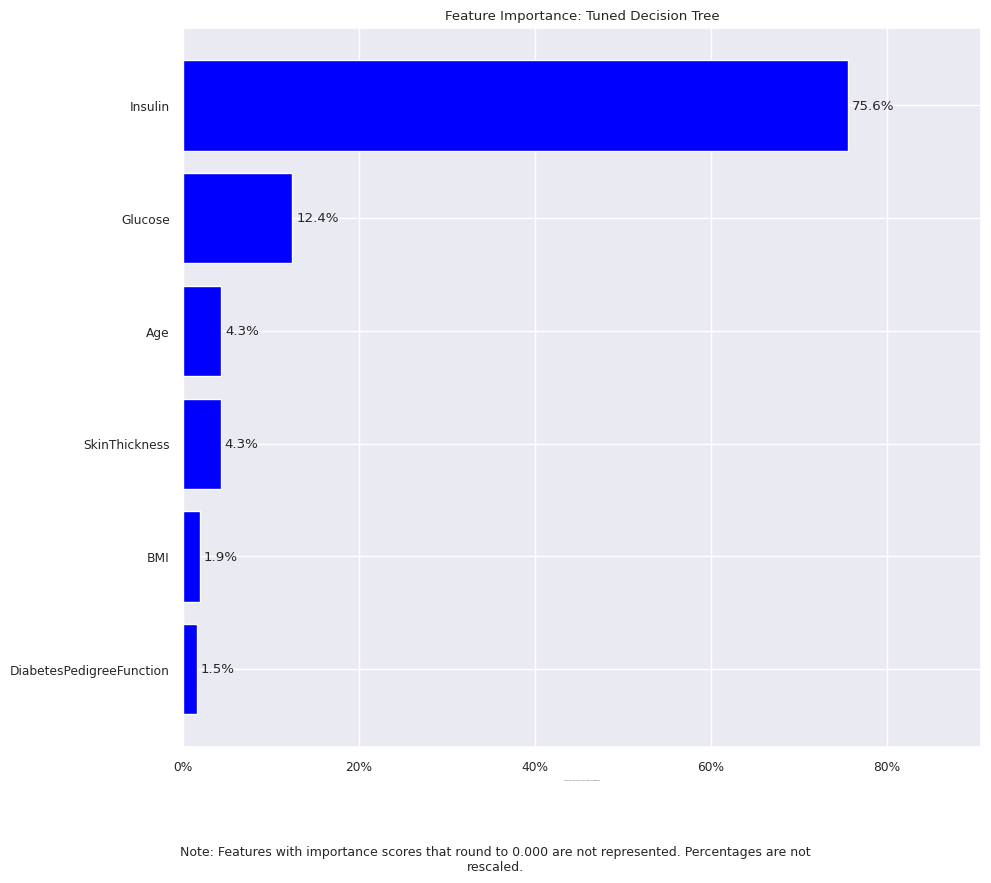

Highest-ranked features in this fitted tree:
- Insulin: 75.6%
- Glucose: 12.4%
- Age: 4.3%

Excluded features (importance rounds to 0.000): Pregnancies, BloodPressure

These percentages describe each feature's share of total impurity reduction, not its effect on diabetes risk.


In [58]:
# @title **Visualize feature importance from the tuned decision tree**

import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.ticker import PercentFormatter

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()
importances = tree_classifier.feature_importances_

# Exclude scores that round to 0.000 at three decimal places.
included = np.round(importances, 3) > 0
excluded_features = feature_names[~included].tolist()

excluded_note = (
    "Excluded features (importance rounds to 0.000): "
    + ", ".join(excluded_features)
    if excluded_features
    else "No features were excluded."
)

if included.any():
    shown_names = feature_names[included]
    shown_importances = importances[included]
    indices = np.argsort(shown_importances)

    note = textwrap.fill(
        "Note: Features with importance scores that round to 0.000 "
        "are not represented. Percentages are not rescaled.",
        width=100
    )
    note_lines = len(note.splitlines())
    bottom_margin = 0.6 + 0.18 * note_lines
    figure_height = 8 + bottom_margin

    fig, ax = plt.subplots(figsize=(10, figure_height))

    bars = ax.barh(
        range(len(indices)),
        shown_importances[indices],
        color="blue"
    )

    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(shown_names[indices])
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

    ax.bar_label(
        bars,
        labels=[f"{value:.1%}" for value in shown_importances[indices]],
        padding=3
    )

    ax.set_xlim(0, shown_importances.max() * 1.2)
    ax.set_xlabel("Feature Importance (% of total impurity reduction)")
    ax.set_title("Feature Importance: Tuned Decision Tree")

    fig.text(
        0.5, 0.02,
        note,
        ha="center",
        va="bottom",
        fontsize=9
    )

    plt.tight_layout(
        rect=[0, bottom_margin / figure_height, 1, 1]
    )
    plt.show()

    print("Highest-ranked features in this fitted tree:")
    for index in indices[::-1][:3]:
        print(f"- {shown_names[index]}: {shown_importances[index]:.1%}")

else:
    print("All feature importance scores round to 0.000; no graph displayed.")

print(f"\n{excluded_note}")
print(
    "\nThese percentages describe each feature's share of total "
    "impurity reduction, not its effect on diabetes risk."
)

# **ADDED MODIFICATIONS**


This section documents everything I added to or changed in the provided notebook. Each change is marked with `#MODIFIED:` in the code, and the new blocks are titled A-D.

---

## Part 1: Four new automated analysis blocks (A-D)

None of these blocks uses machine learning or changes `df`, so the original ML results are unaffected.

| Block | Location | What it automates | Conditional logic | Key setting(s) |
|---|---|---|---|---|
| **A. Data quality report** | After the missing-value check | Labels every column OK, Minor, or PROBLEM | `if / elif / else` chain: impossible zeros → too many missing → some missing → OK | `zero_not_allowed`, `missing_limit` |
| **B. Variable-type detection** | After "View 15 random rows" | Decides categorical vs numeric, then mean vs median | Nested `if / else` on number of unique values, then on the mean-median gap | `max_categories`, `skew_limit` |
| **C. Risk groups** | After the last plot | Bins BMI, Age, or Glucose into labeled groups and computes diabetes rates | A dictionary picks the grouping function; `if` checks the variable is supported; a loop warns about small groups | `GROUP_VARIABLE`, `small_group_size` |
| **D. Outlier check** | After Block C | IQR outlier detection with a summary/detail switch | `if` validates `REPORT_MODE`; `if / elif / else` labels each variable; detail mode adds extra output | `REPORT_MODE`, `outlier_limit`, `multiplier` |

### Results of the original runs
- **Block A:** No problems found. No impossible zeros and no column above the 5% missing limit, so the PROBLEM branches were never triggered.
- **Block B:** Four numeric predictors were called skewed (mean and median differ by more than 10%): Insulin (38.3%), Pregnancies (28.2%), DiabetesPedigreeFunction (26.7%) and Age (14.6%). Glucose (4.0%), BloodPressure (0.5%), SkinThickness (3.9%) and BMI (1.2%) were roughly symmetric. Outcome (2 unique values) was treated as categorical.
- **Block C (BMI):** A warning fired because the Underweight group has only 4 people, so its diabetes percentage is unreliable.
- **Block D:** `SkinThickness`, `Insulin`, `BMI`, and `DiabetesPedigreeFunction` were all flagged for having some outliers.

---

## Part 2: Modifications to existing settings

| # | Cell | Before → After | Why it suits this dataset |
|---|---|---|---|
| 1 | Chi-square test | `threshold = 10` → `6` | Few women have more than 10 pregnancies, so the original "above threshold" group is small. A cutoff of 6 gives larger, more balanced groups. |
| 2 | Block B | `max_categories = 10` → `20` | Pregnancies is a count with 17 distinct values. A frequency table can be more informative than a mean. |
| 3 | Block D | `multiplier = 1.5` → `3`, and `REPORT_MODE = "summary"` → `"detail"` | Insulin and DiabetesPedigreeFunction are skewed (Block B), so the standard rule likely over-flags their long tails. A multiplier of 3 keeps only extreme values. |
| 4 | Random-rows cell | `np.random.seed()` → `np.random.seed(42)` | A fixed seed means the same 15 rows appear on every run (reproducibility). |
| 5 | Block 9 | `'D_BP'` → `'BloodPressure'`, `'Skin_Thickness'` → `'SkinThickness'` | The original names did not match the dataset's columns, so those two columns were silently skipped. |

---

## Part 3: Additional enhancements

1. **New conditional logic in Block C.** The code now prints whether the diabetes rate rises, falls, or has no consistent trend across groups. For BMI, the diabetes rate rises across the groups, from 0.0% for Underweight to 45.8% for Obese. However, the Underweight group contains only 4 people, so its 0.0% rate is unreliable; despite this, the overall increasing trend remains clear. For Age, the diabetes rate rises across age groups. For Glucose, the diabetes rate also rises across glucose groups.
2. **Unused function put to use.** `get_metrics_score` was defined in the template but never called. A new cell calls it for the logistic regression and the tuned decision tree to compare training and test performance. For logistic regression, training vs. test accuracy was 0.799 vs. 0.749, recall was 0.620 vs. 0.580, precision was 0.758 vs. 0.662, and F1 was 0.682 vs. 0.618. For the tuned decision tree, training vs. test accuracy was 0.926 vs. 0.848, recall was 0.877 vs. 0.728, precision was 0.906 vs. 0.819, and F1 was 0.891 vs. 0.771. The decision tree has noticeably larger training-test gaps, especially for recall and F1, suggesting some overfitting, while logistic regression shows smaller gaps and better generalization.
3. **New explanation cells.** I added Markdown explaining why inferential statistics matters and how the machine learning section works (logistic regression, decision tree, metrics, cutoff selection).
4. **Documentation fixes.** I corrected broken Markdown headings for Blocks B, C and D, and updated Block A's "What to look for" section to match the real output.
5. **Version cell.** A final code cell prints the library versions used.

---

## Part 4: How the modifications show conditional logic

- Changing `max_categories` changes which **branch** Block B takes for Pregnancies.
- Changing `multiplier` moves variables between the **REVIEW**, **Some outliers** and **No outliers** labels.
- Switching `REPORT_MODE` changes how much output is produced.
- Changing `GROUP_VARIABLE` changes which grouping **function** the dictionary selects.
- The new trend check chooses one of three messages from the data.

---

## Part 5: Why the choices were appropriate

The outlier modification had the largest effect because increasing the IQR multiplier from 1.5 to 3 made the analysis focus on only the most extreme observations. This was appropriate for skewed variables such as Insulin, where a standard 1.5 multiplier could flag many values that are part of the variable’s natural long tail rather than truly unusual observations. Lowering the pregnancy threshold from 10 to 6 also created larger and more balanced groups, making the chi-square comparison more stable. Finally, comparing training and test metrics showed that the tuned decision tree had larger performance gaps than logistic regression, suggesting some overfitting and demonstrating why test-set performance is important when evaluating how well a model generalizes.

---

## Part 6: Verification and limitations

- I ran **Runtime → Restart session and run all**, and the notebook completed without errors.
- All random processes use a fixed seed (`random_state=42` for the split and models, `np.random.seed(42)` for sampling).
- Limitations: Not for clinical use.